# Level 3 — Skin wound neighborhood theme analysis (per-cell)

Per-cell functional **signature scoring** for the nine wound-biology themes
requested by the collaborator, read out in a spatial / neighborhood context.

For each theme we (1) define a gene signature restricted to genes on the Xenium
panel, (2) compute a per-cell module score (`sc.tl.score_genes`), and (3)
summarize those scores spatially, per **cell lineage (compartment)**, and per
**CellCharter niche** (k=12).

**Themes:** wound healing & epithelial repair · vascular repair · immunity &
recruitment · inflammation & resolution · fibrosis & matrix remodeling ·
neuroimmune signaling · pain & sensory transduction · neuropeptides & receptors ·
neurogenic inflammation.

> **⚠️ Caveat (see final cell):** the four *neuro/sensory* themes have very low
> signal in this dataset. The genes are on the panel, but sensory-neuron cell
> bodies (which express them) reside in the dorsal root ganglia, not the skin —
> the skin contains only thin axons that Xenium does not segment into cells.
> Interpret per-cell pain/neuropeptide scores with caution.

Input: `../../data/talbot_xenium_skin_annotated_cellcharter.h5ad` (log-normalized
`X`, CyteType annotation, CellCharter niches, `obsm['spatial']`).

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import warnings; warnings.filterwarnings('ignore')
sc.settings.verbosity = 1

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Load object + define compartments (coarse cell lineages)

In [2]:
adata = sc.read_h5ad('../../data/talbot_xenium_skin_annotated_cellcharter.h5ad')
ANNOT = 'cytetype_annotation_leiden_4'
NICHE = 'CellCharter_12'

def coarse(s):
    s = s.lower()
    if 'doublet' in s or 'mixed' in s: return 'Mixed'
    if any(k in s for k in ['macrophage','myeloid','dendritic','mast','neutro',
                            'monocyte','langerhans','immune','t cell','b cell','lymph']):
        return 'Immune'
    if any(k in s for k in ['endothel','vascular','vessel','lymphatic']): return 'Endothelial'
    if 'fibro' in s or 'stromal' in s: return 'Fibroblast'
    if 'muscle' in s or 'myocyte' in s: return 'Muscle'
    if 'adipo' in s: return 'Adipocyte'
    if any(k in s for k in ['kerat','epithel','epiderm']): return 'Keratinocyte'
    if any(k in s for k in ['schwann','neuro','glia','nerve','melanocyte']): return 'Neural/Melanocyte'
    return 'Other'

adata.obs['compartment'] = adata.obs[ANNOT].astype(str).map(coarse)
print(adata.obs['compartment'].value_counts())
adata

compartment
Keratinocyte    27078
Immune          18083
Fibroblast      14921
Endothelial      8932
Muscle           4698
Adipocyte        2429
Other             954
Mixed             306
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 77401 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4', '_scvi_batch', '_scvi_labels', 'CellCharter_8', 'CellCharter_10', 'CellCharter_12', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cytetype_annotation_leiden_4_colors', 'cytetype_jobDetails', 'cytetype_results', 'genotyp

## Theme gene signatures (restricted to the Xenium panel)

In [3]:
THEMES = {
    'wound_healing':          ['Lgr5','Lgr6','Wnt5a','Wnt4','Fgf7','Egfr','Ereg','Tgfb1','Ctnnb1','Itgb1','Itgb4','Lamb3','Cdh1','Timp1','Serpine1'],
    'vascular_repair':        ['Pecam1','Cdh5','Vwf','Kdr','Flt1','Flt4','Tek','Vegfa','Vegfc','Angpt1','Angpt2','Nos3','Notch1','Dll4','Hey1','Eng','Pdgfrb','Cspg4'],
    'immunity_recruitment':   ['Ptprc','Cd3e','Cd4','Cd8a','Cd19','Ms4a1','Cd68','Adgre1','Itgam','Ccr2','Ccl2','Ccl3','Cxcl1','Cxcl2','Cxcl9','Cxcl10','Cxcl12','Ccr7','Sell','Il7r','Cd14'],
    'inflammation_resolution':['Tnf','Nfkb1','Ptgs2','Nlrp3','Il10','Tgfb1','Arg1','Mrc1','Chil3','Alox15','Fpr2','Il4','Il13','Socs3','Foxp3','Nos2'],
    'fibrosis_matrix':        ['Col1a1','Col1a2','Col5a1','Col6a1','Fn1','Tagln','Postn','Timp1','Mmp2','Mmp9','Mmp13','Mmp14','Lox','Loxl1','Fbn1','Eln','Tgfb1','Pdgfra','Pdgfrb','Lum'],
    'neuroimmune':            ['Ngf','Bdnf','Ntrk1','Ntrk2','Gfra1','Ret','Nrg1','Cx3cl1','Cx3cr1','Csf1','Csf1r','Il31','Osm','Osmr','Tslp','Crlf2'],
    'pain_sensory':           ['Trpv1','Trpa1','Trpm8','Scn9a','Scn10a','Piezo2','Piezo1','Asic1','Asic3','P2rx3','P2rx7','Gfra3','Runx1','Trpv4','Kcnq3'],
    'neuropeptides':          ['Calcr','Calcrl','Tac1','Tacr1','Tacr2','Vip','Vipr1','Vipr2','Npy1r','Sst','Sstr2','Gal','Galr1','Pnoc','Oprm1','Oprd1','Oprk1','Adcyap1','Nppb','Grp','Grpr','Nmb'],
    'neurogenic_inflammation':['Tac1','Tacr1','Trpv1','Trpa1','Adcyap1','Vip','Hrh1','Ccl2','Ngf'],
}
THEME_LABEL = {
    'wound_healing':'Wound healing & epithelial repair',
    'vascular_repair':'Vascular repair',
    'immunity_recruitment':'Immunity & recruitment',
    'inflammation_resolution':'Inflammation & resolution',
    'fibrosis_matrix':'Fibrosis & matrix remodeling',
    'neuroimmune':'Neuroimmune signaling',
    'pain_sensory':'Pain & sensory transduction',
    'neuropeptides':'Neuropeptides & receptors',
    'neurogenic_inflammation':'Neurogenic inflammation',
}
panel = set(map(str, adata.var_names))
cov = []
for t, gs in THEMES.items():
    on = [g for g in gs if g in panel]
    THEMES[t] = on
    cov.append({'theme': t, 'label': THEME_LABEL[t], 'n_genes_on_panel': len(on),
                'genes': ';'.join(on)})
cov = pd.DataFrame(cov)
os.makedirs('../../results/cell-driven-analysis', exist_ok=True)
cov.to_csv('../../results/cell-driven-analysis/skin_wound_theme_gene_panel.csv', index=False)
cov[['theme','n_genes_on_panel']]

,theme,n_genes_on_panel
0,wound_healing,15
1,vascular_repair,18
2,immunity_recruitment,21
3,inflammation_resolution,16
4,fibrosis_matrix,20
5,neuroimmune,16
6,pain_sensory,15
7,neuropeptides,22
8,neurogenic_inflammation,9


## Per-cell module scores (`sc.tl.score_genes`)

In [4]:
score_cols = []
for t, gs in THEMES.items():
    col = f'{t}_score'
    sc.tl.score_genes(adata, gene_list=gs, score_name=col, ctrl_size=50, random_state=0)
    score_cols.append(col)
adata.obs[score_cols].describe().T[['mean','std','min','max']]

,mean,std,min,max
wound_healing_score,0.023113,0.056461,-0.059322,0.465648
vascular_repair_score,-0.005412,0.033678,-0.043246,0.406673
immunity_recruitment_score,-0.001695,0.039766,-0.041386,0.352187
inflammation_resolution_score,0.000684,0.034477,-0.036968,0.346772
fibrosis_matrix_score,0.041779,0.105333,-0.069977,0.563548
neuroimmune_score,-0.002299,0.023559,-0.029644,0.281236
pain_sensory_score,-0.001545,0.015870,-0.032928,0.203079
neuropeptides_score,-0.000620,0.007489,-0.024683,0.128824
neurogenic_inflammation_score,-0.010585,0.031271,-0.050883,0.392490


## Spatial maps of each theme score (per condition, 6 panels)

Continuous per-cell score, shared 1st–99th-percentile color scale within each
theme so panels are comparable across conditions.

In [5]:
CONDS = ['litt_24h','cre_24h','wt_24h','litt_72h','cre_72h','wt_72h']

def plot_score_by_condition(ad, score_col, out_stem=None, cmap='magma',
                            spot_size=2.0, cols=3, title=None):
    coords = np.asarray(ad.obsm['spatial'])[:, :2]
    vals = ad.obs[score_col].to_numpy()
    vmin, vmax = np.percentile(vals, [1, 99])
    if vmin == vmax:
        vmin, vmax = float(vals.min()), float(vals.max() + 1e-9)
    conds = [c for c in CONDS if c in set(ad.obs['condition'].astype(str))]
    n = len(conds); ncol = min(cols, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.4, nrow * 3.4), dpi=110)
    axes = np.atleast_1d(axes).ravel()
    cond = ad.obs['condition'].astype(str).to_numpy()
    sca = None
    for ax, cnd in zip(axes, conds):
        m = cond == cnd
        order = np.argsort(vals[m])          # draw high-score cells on top
        sca = ax.scatter(coords[m, 0][order], coords[m, 1][order], s=spot_size,
                         c=vals[m][order], cmap=cmap, vmin=vmin, vmax=vmax,
                         linewidths=0, rasterized=True)
        ax.set_title(cnd, fontsize=9)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    cbar = fig.colorbar(sca, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label('module score', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    if out_stem:
        os.makedirs(os.path.dirname(out_stem), exist_ok=True)
        fig.savefig(out_stem + '.png', dpi=110, bbox_inches='tight')
        fig.savefig(out_stem + '.pdf', bbox_inches='tight')
        print('saved', out_stem + '.png/.pdf')
    plt.show()

saved ../../results/spatial-tissue-maps/skin_wound_theme_wound_healing_by_condition.png/.pdf


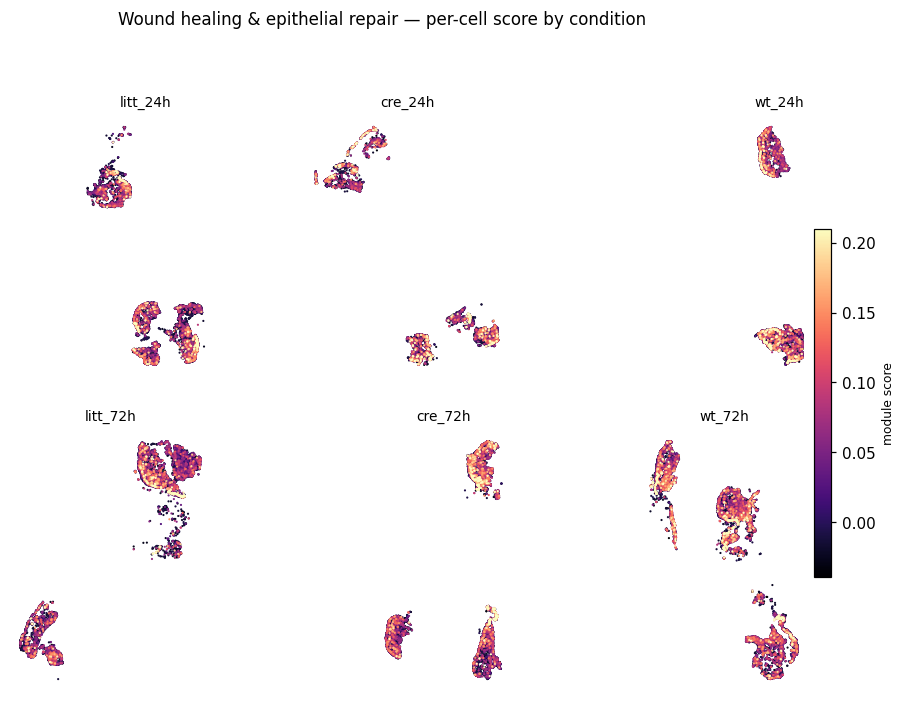

saved ../../results/spatial-tissue-maps/skin_wound_theme_vascular_repair_by_condition.png/.pdf


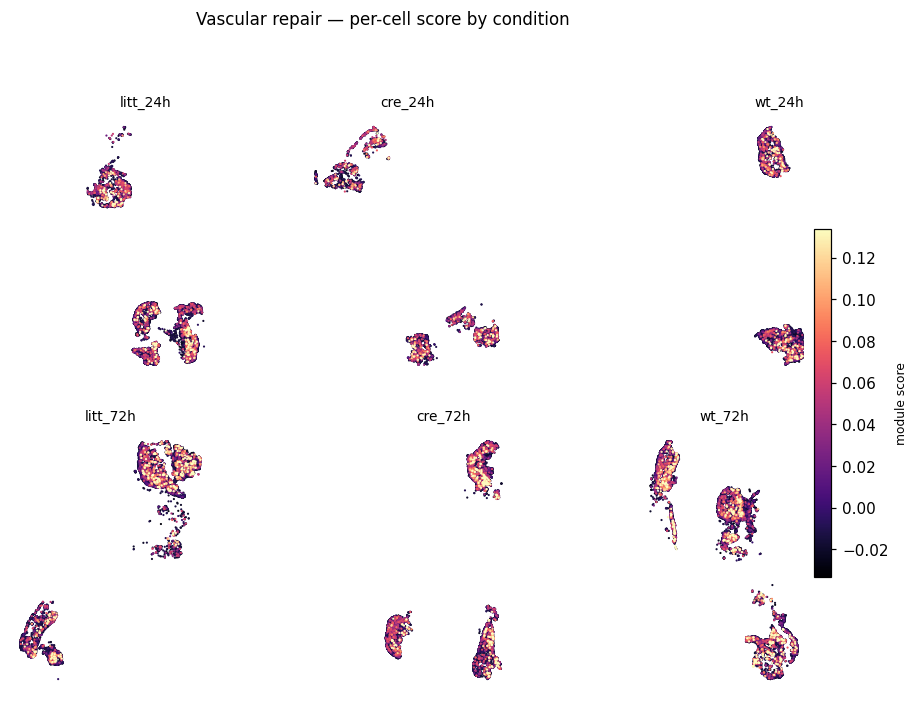

saved ../../results/spatial-tissue-maps/skin_wound_theme_immunity_recruitment_by_condition.png/.pdf


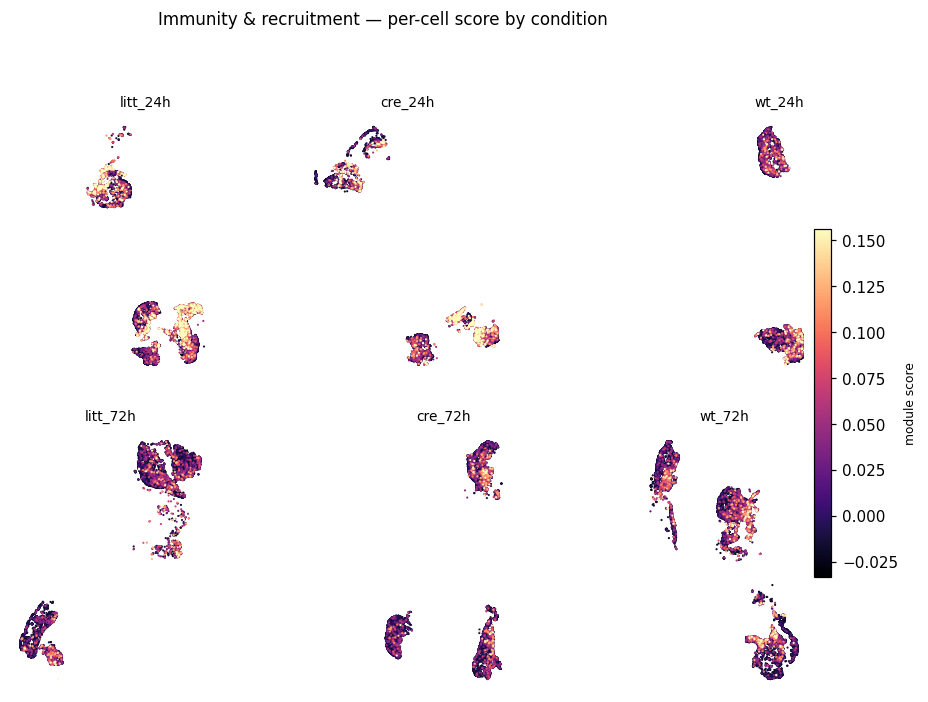

saved ../../results/spatial-tissue-maps/skin_wound_theme_inflammation_resolution_by_condition.png/.pdf


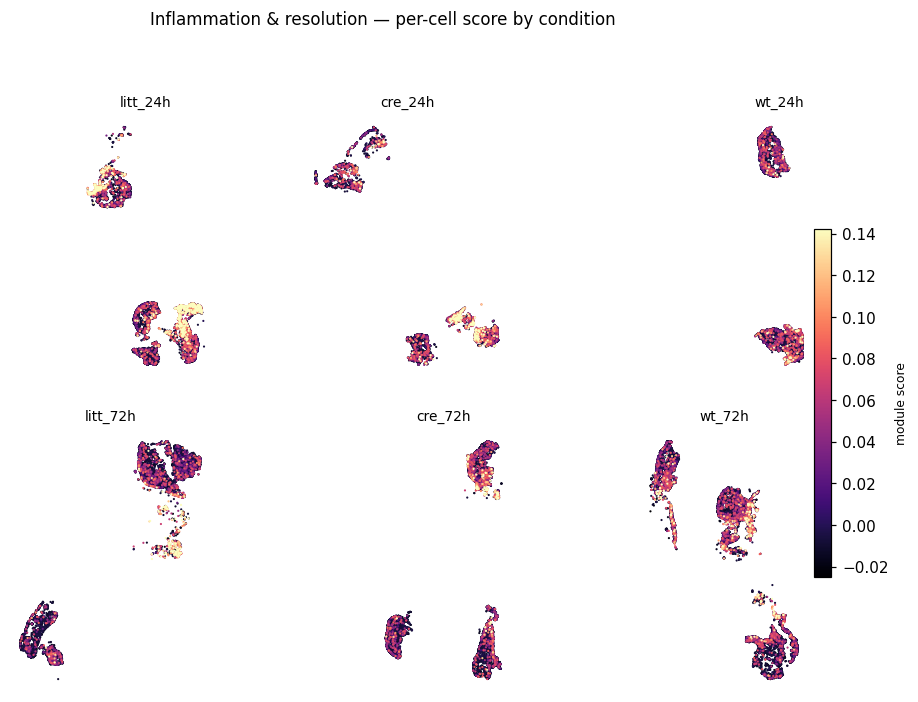

saved ../../results/spatial-tissue-maps/skin_wound_theme_fibrosis_matrix_by_condition.png/.pdf


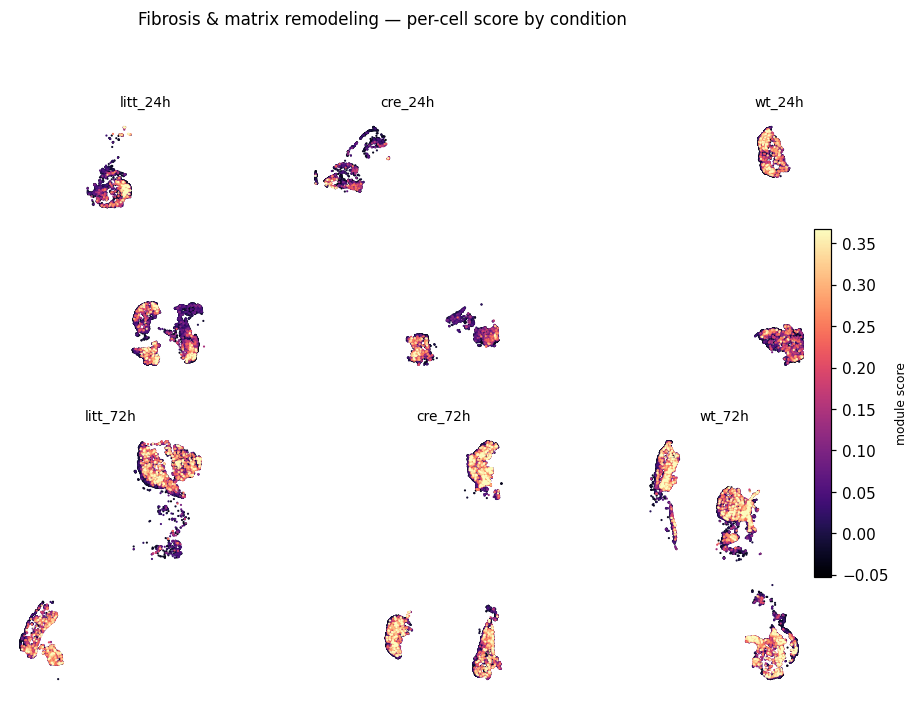

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuroimmune_by_condition.png/.pdf


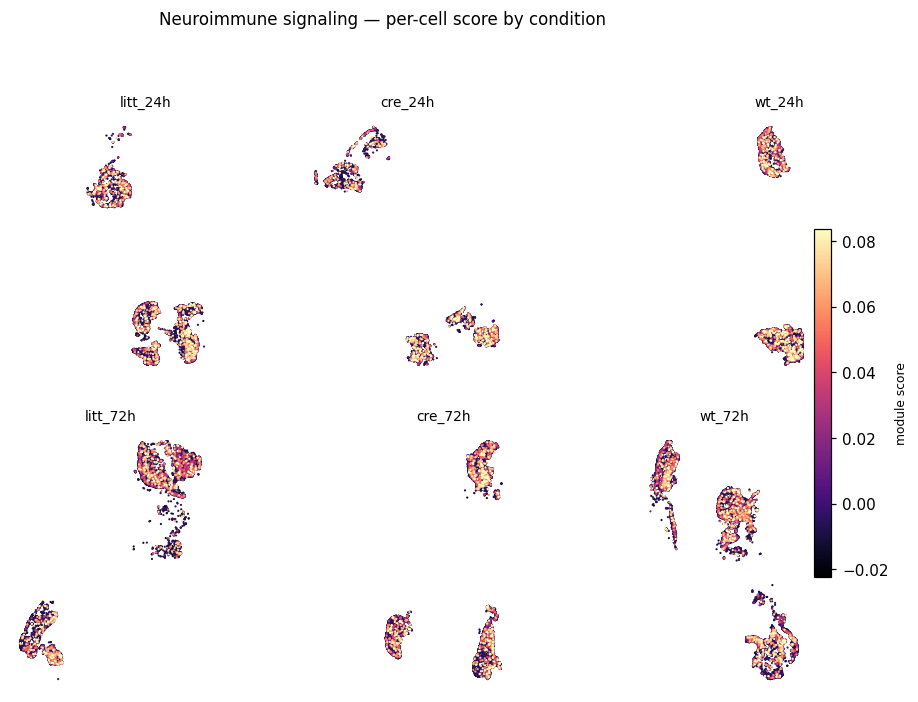

saved ../../results/spatial-tissue-maps/skin_wound_theme_pain_sensory_by_condition.png/.pdf


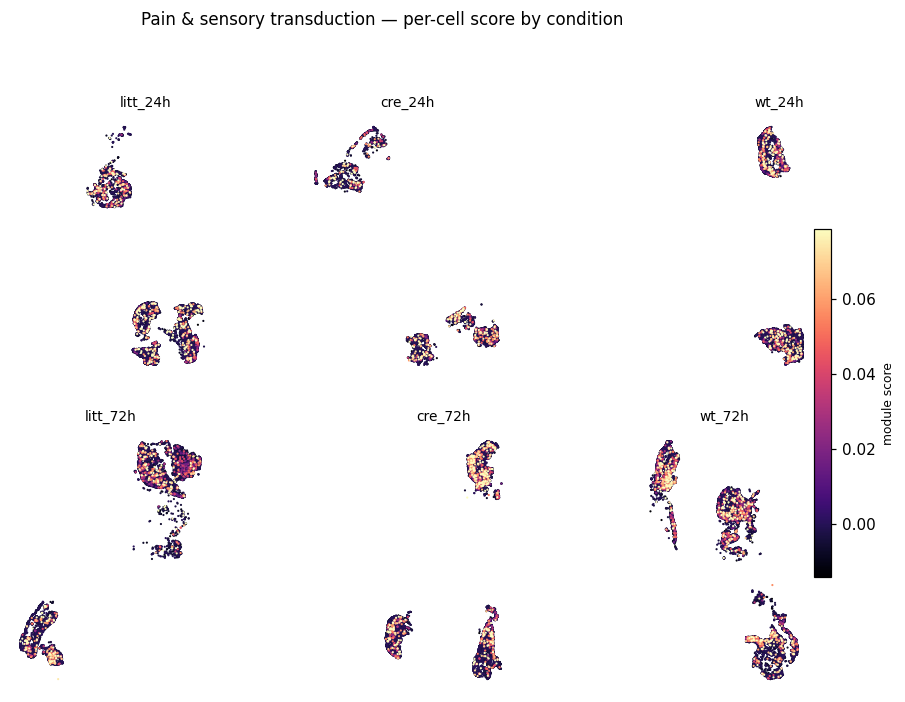

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuropeptides_by_condition.png/.pdf


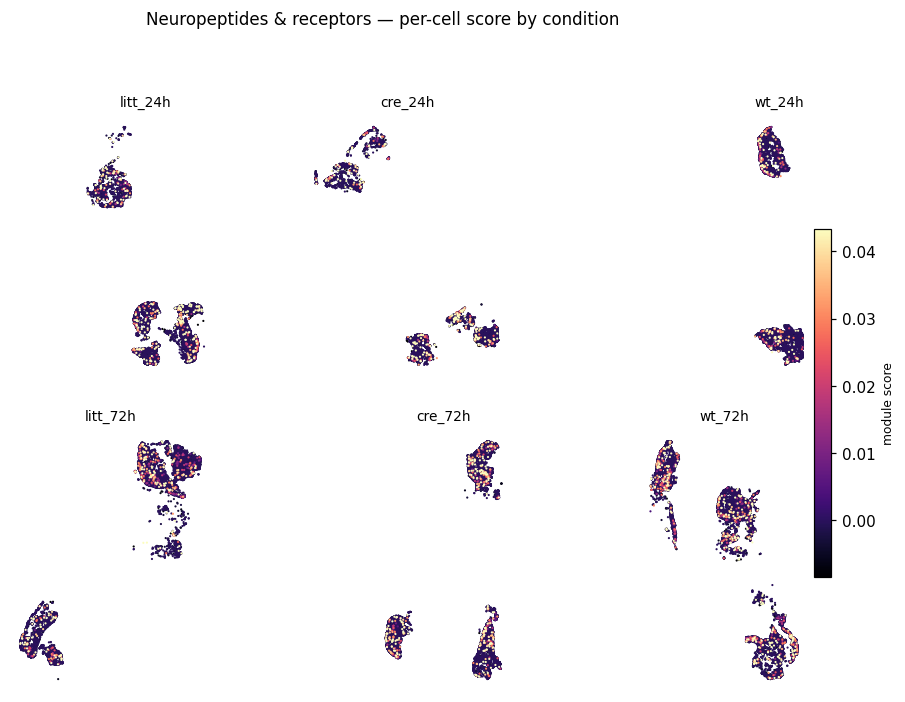

saved ../../results/spatial-tissue-maps/skin_wound_theme_neurogenic_inflammation_by_condition.png/.pdf


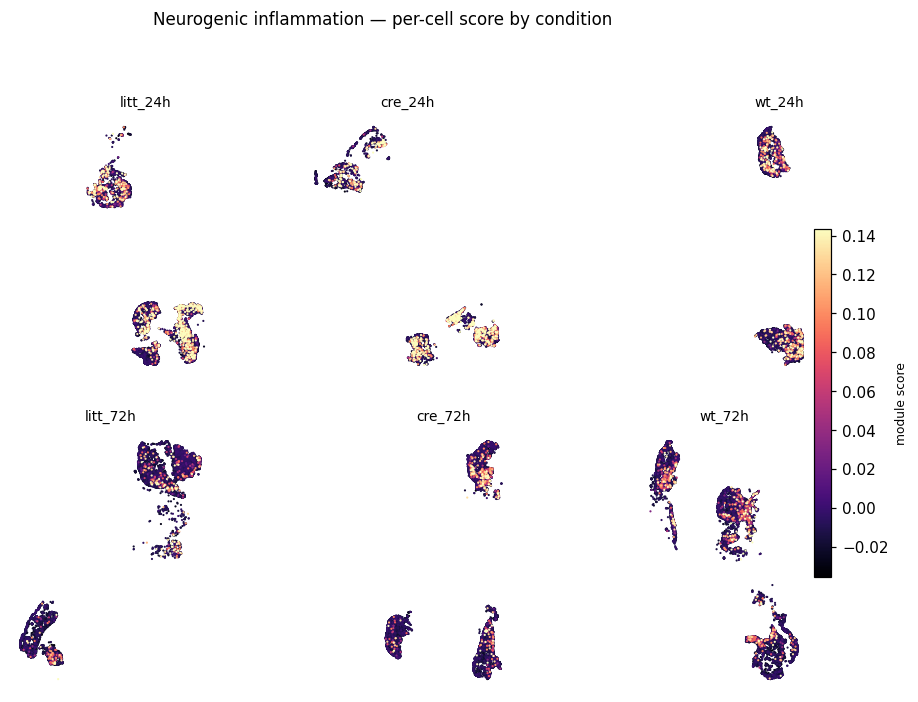

In [6]:
for t in THEMES:
    plot_score_by_condition(
        adata, f'{t}_score',
        out_stem=f'../../results/spatial-tissue-maps/skin_wound_theme_{t}_by_condition',
        title=f'{THEME_LABEL[t]} — per-cell score by condition')

## Spatial maps of each theme score (per sample)

Same continuous scores, one panel per `sample_id` (short `condition_section`
titles). Useful for spotting section-to-section / replicate variability.

In [7]:
def plot_score_by_sample(ad, score_col, out_stem=None, cmap='magma',
                         groupby='sample_id', spot_size=3, cols=6, height=2.6,
                         dpi=110, title=None):
    coords = np.asarray(ad.obsm['spatial'])[:, :2]
    vals = ad.obs[score_col].to_numpy()
    vmin, vmax = np.percentile(vals, [1, 99])
    if vmin == vmax:
        vmin, vmax = float(vals.min()), float(vals.max() + 1e-9)
    samples = list(pd.unique(ad.obs[groupby].astype(str)))
    cond_of = ad.obs.groupby(groupby, observed=True)['condition'].first().astype(str).to_dict()
    short = {s: f"{cond_of.get(s, s)}_{s.rsplit('_', 1)[-1]}" for s in samples}
    n = len(samples); ncol = min(cols, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * height, nrow * height), dpi=dpi)
    axes = np.atleast_1d(axes).ravel()
    sid = ad.obs[groupby].astype(str).to_numpy()
    sca = None
    for ax, s in zip(axes, samples):
        m = sid == s
        order = np.argsort(vals[m])
        sca = ax.scatter(coords[m, 0][order], coords[m, 1][order], s=spot_size,
                         c=vals[m][order], cmap=cmap, vmin=vmin, vmax=vmax,
                         linewidths=0, rasterized=True)
        ax.set_title(short[s], fontsize=8)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    cbar = fig.colorbar(sca, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label('module score', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    if out_stem:
        os.makedirs(os.path.dirname(out_stem), exist_ok=True)
        fig.savefig(out_stem + '.png', dpi=dpi, bbox_inches='tight')
        fig.savefig(out_stem + '.pdf', bbox_inches='tight')
        print('saved', out_stem + '.png/.pdf')
    plt.show()

saved ../../results/spatial-tissue-maps/skin_wound_theme_wound_healing_by_sample.png/.pdf


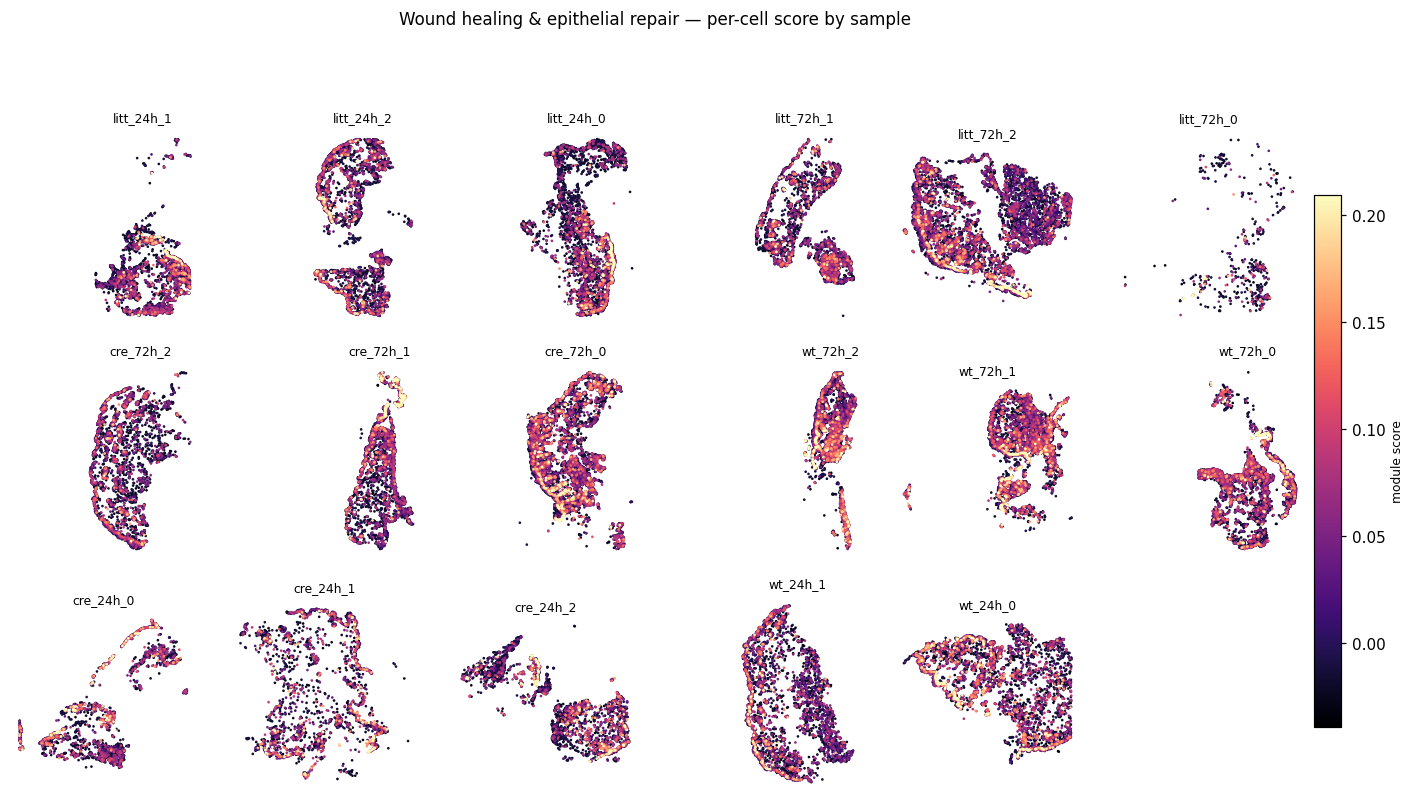

saved ../../results/spatial-tissue-maps/skin_wound_theme_vascular_repair_by_sample.png/.pdf


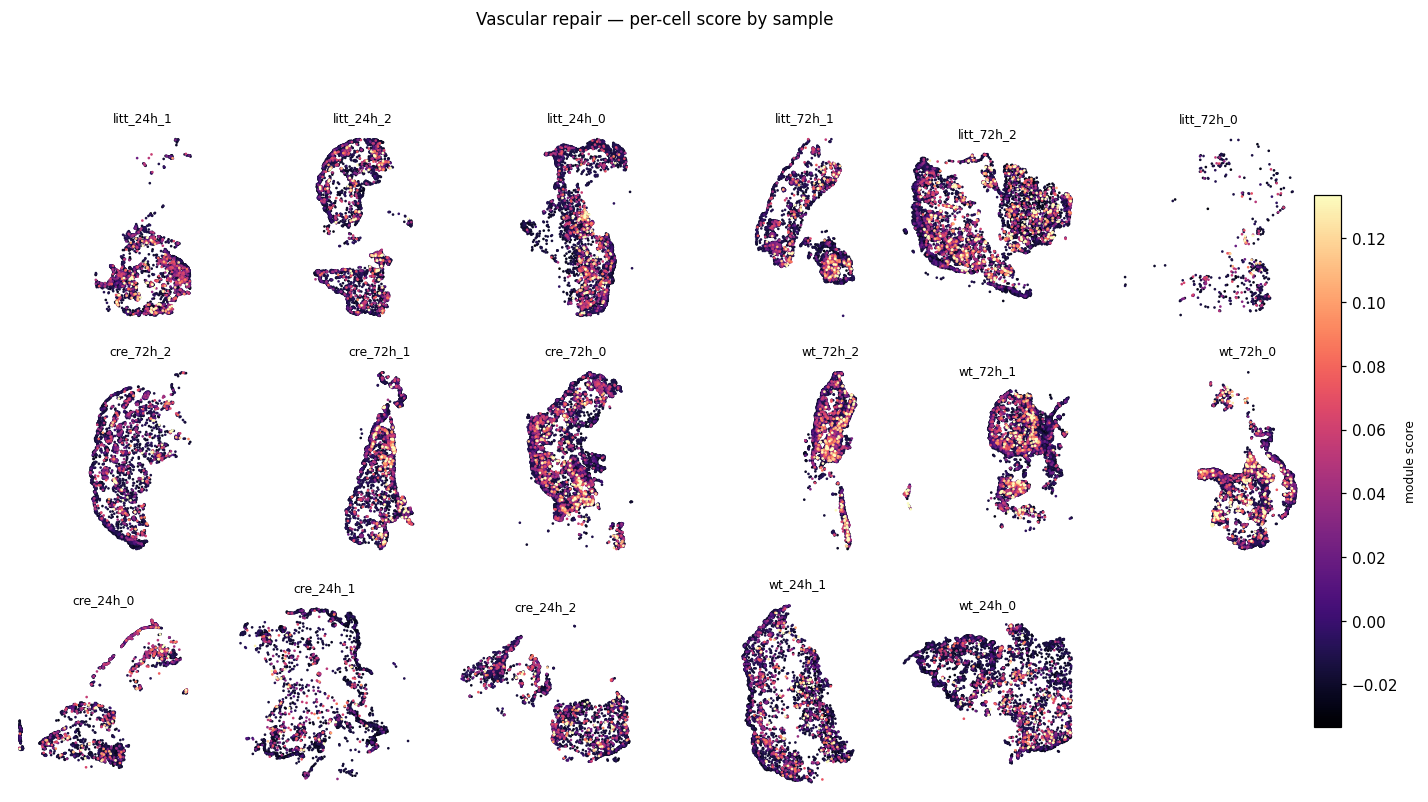

saved ../../results/spatial-tissue-maps/skin_wound_theme_immunity_recruitment_by_sample.png/.pdf


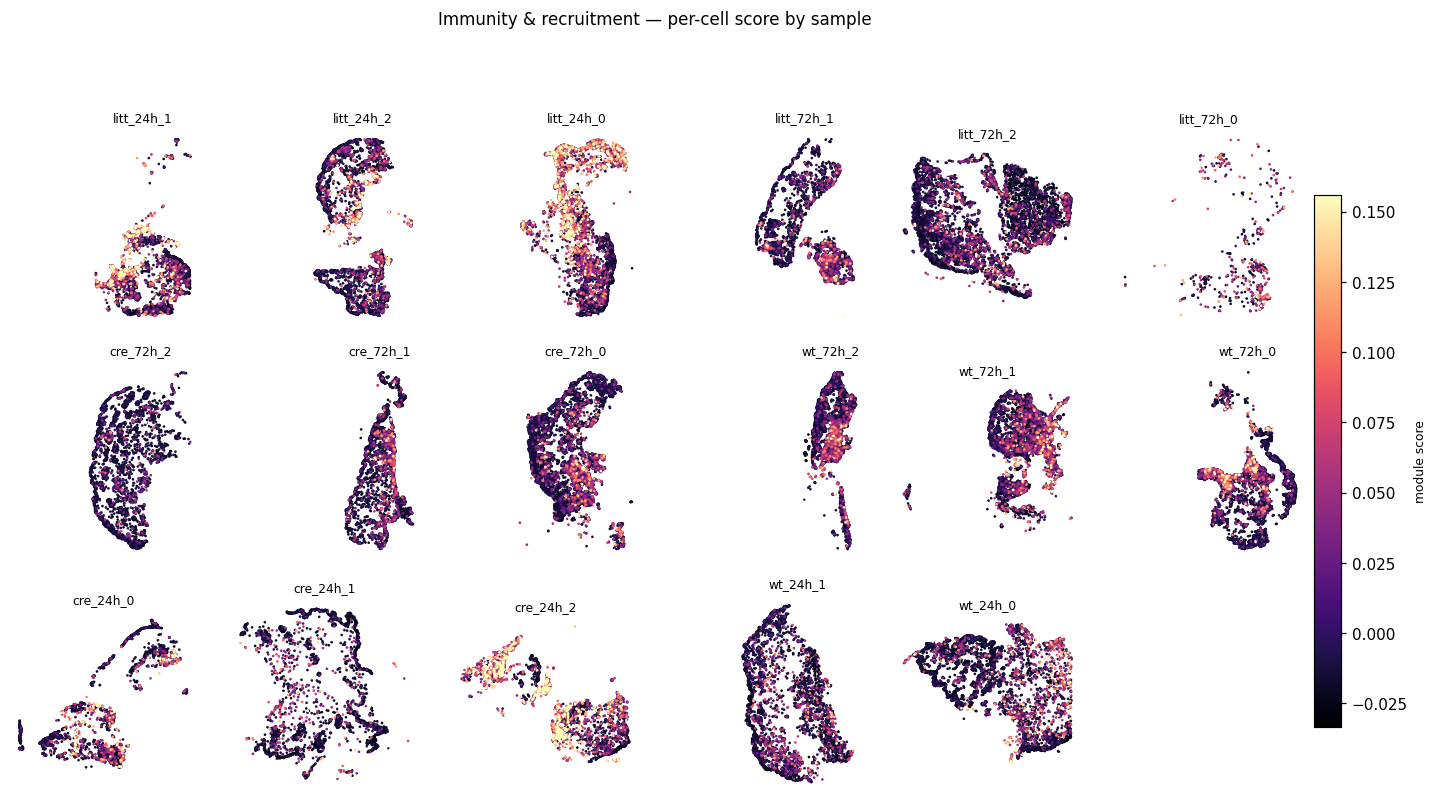

saved ../../results/spatial-tissue-maps/skin_wound_theme_inflammation_resolution_by_sample.png/.pdf


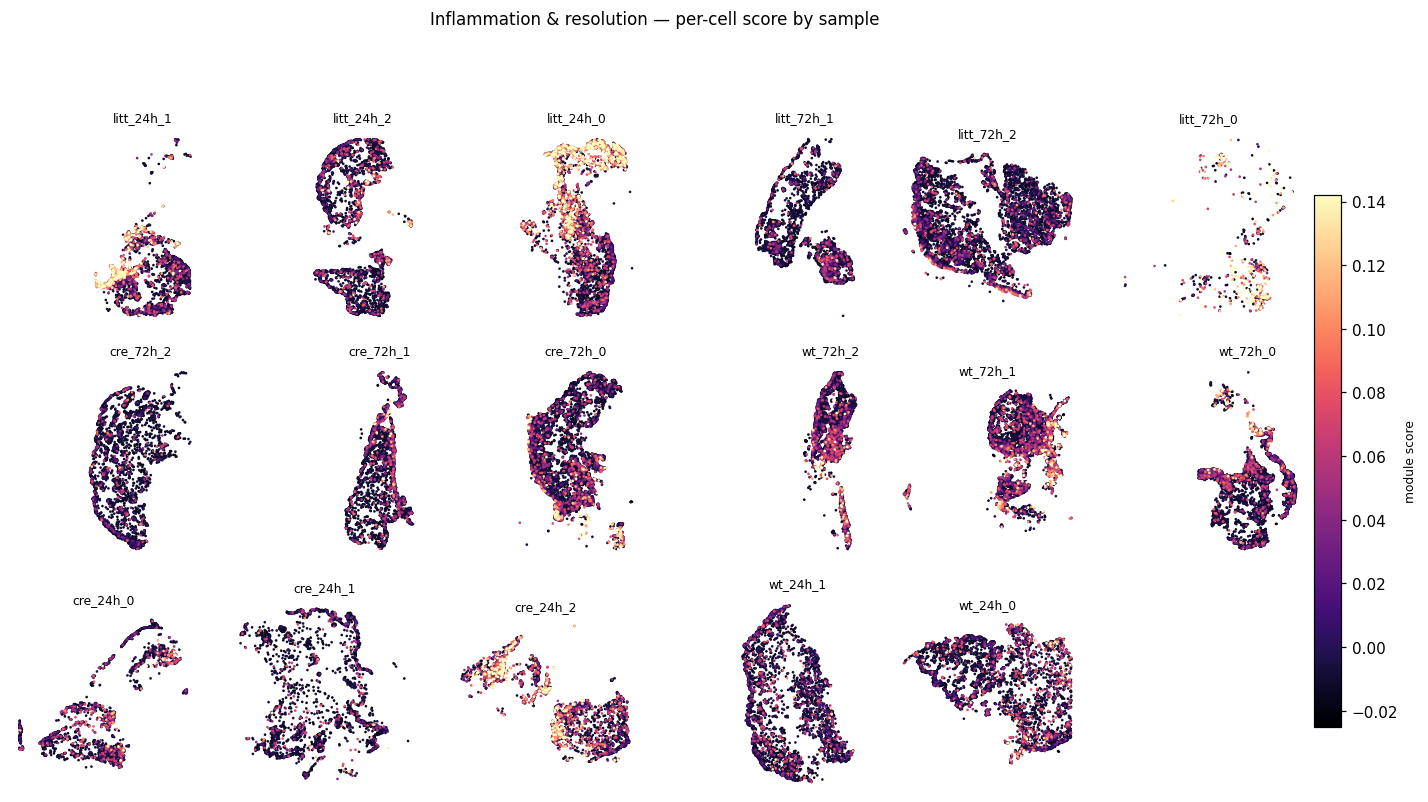

saved ../../results/spatial-tissue-maps/skin_wound_theme_fibrosis_matrix_by_sample.png/.pdf


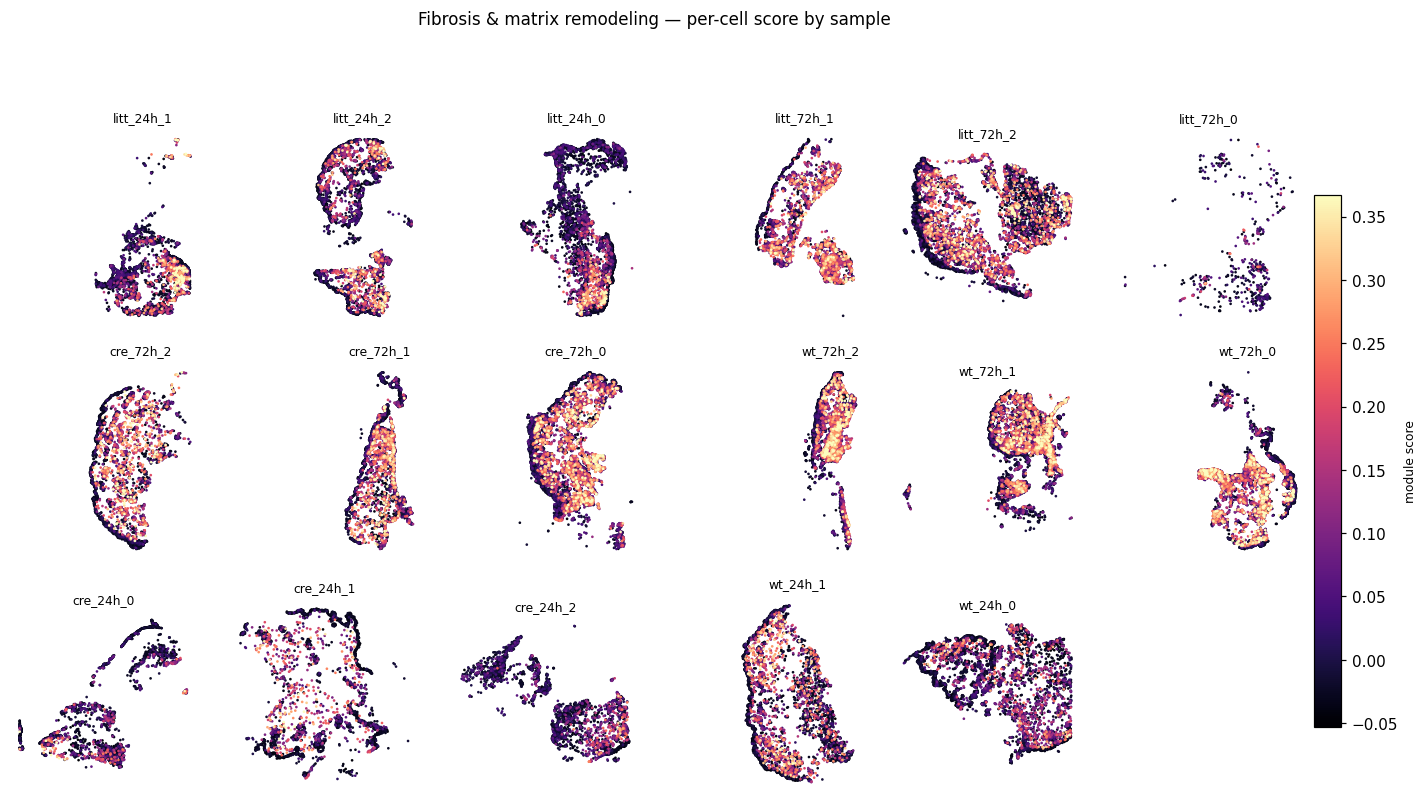

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuroimmune_by_sample.png/.pdf


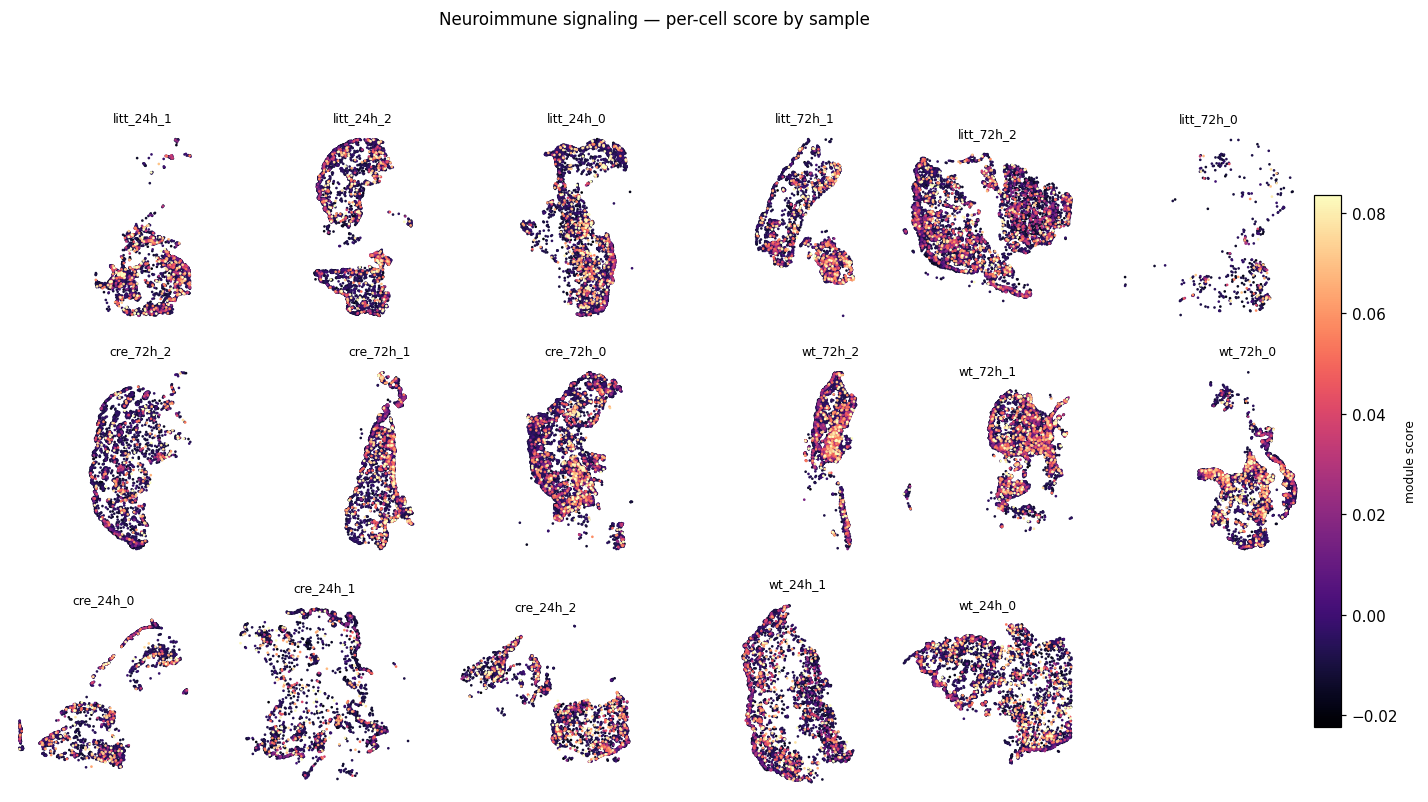

saved ../../results/spatial-tissue-maps/skin_wound_theme_pain_sensory_by_sample.png/.pdf


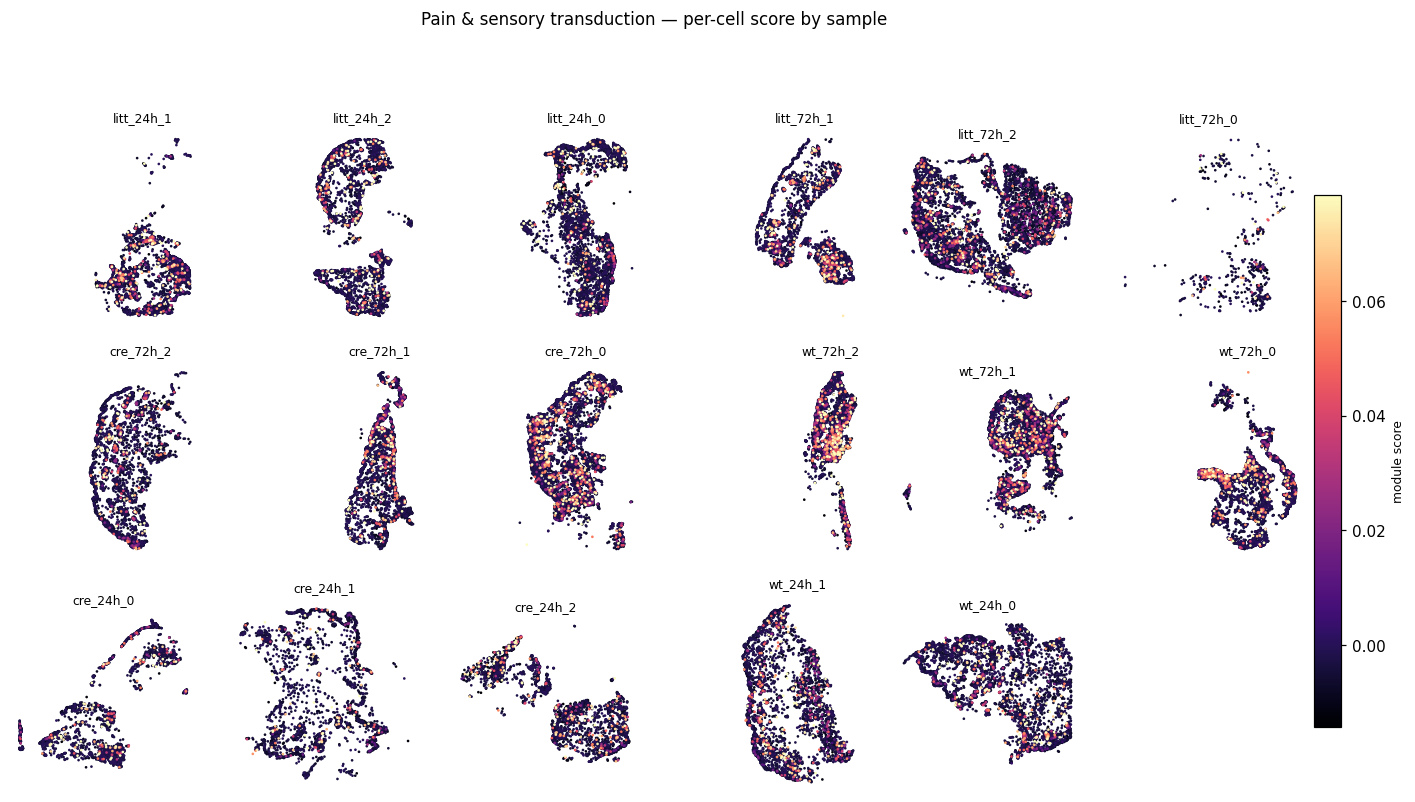

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuropeptides_by_sample.png/.pdf


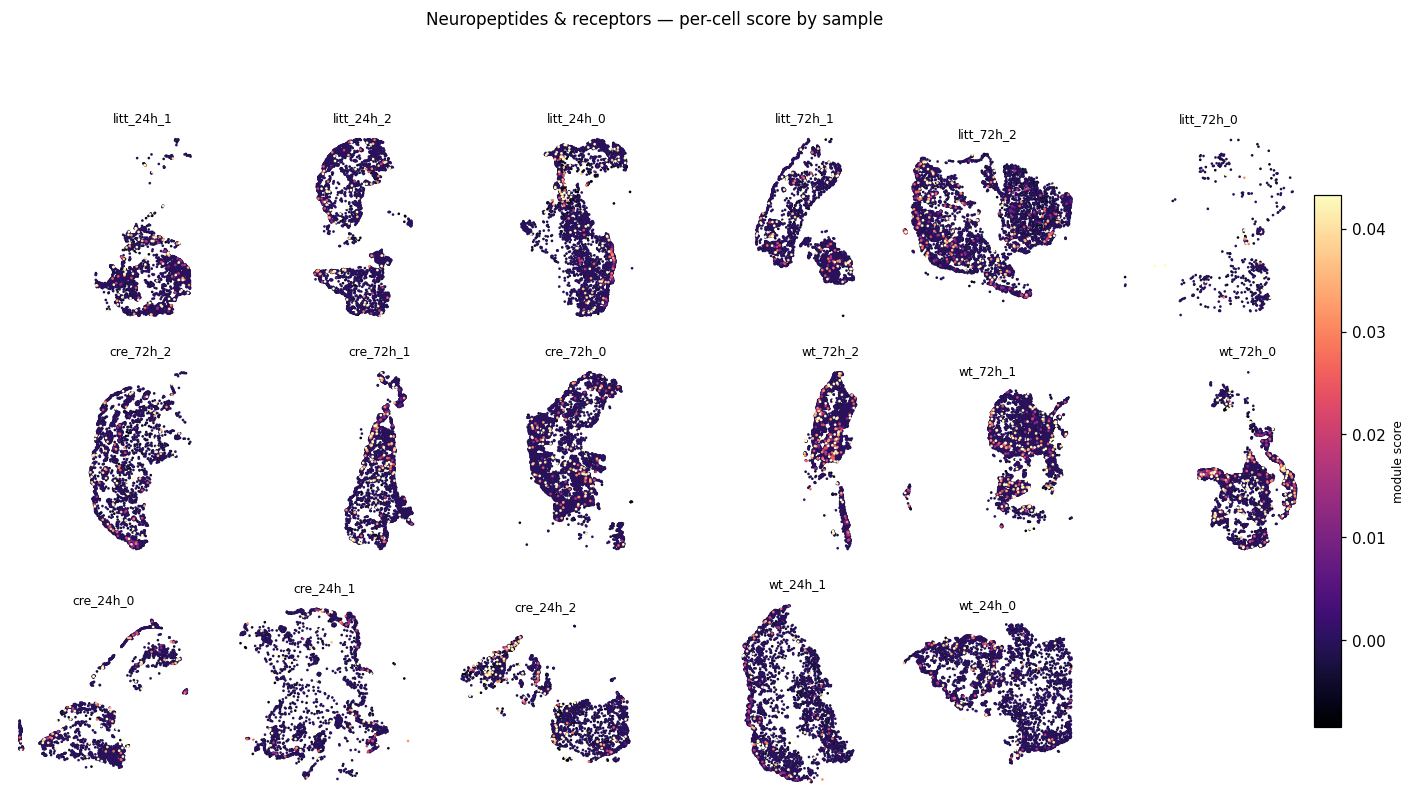

saved ../../results/spatial-tissue-maps/skin_wound_theme_neurogenic_inflammation_by_sample.png/.pdf


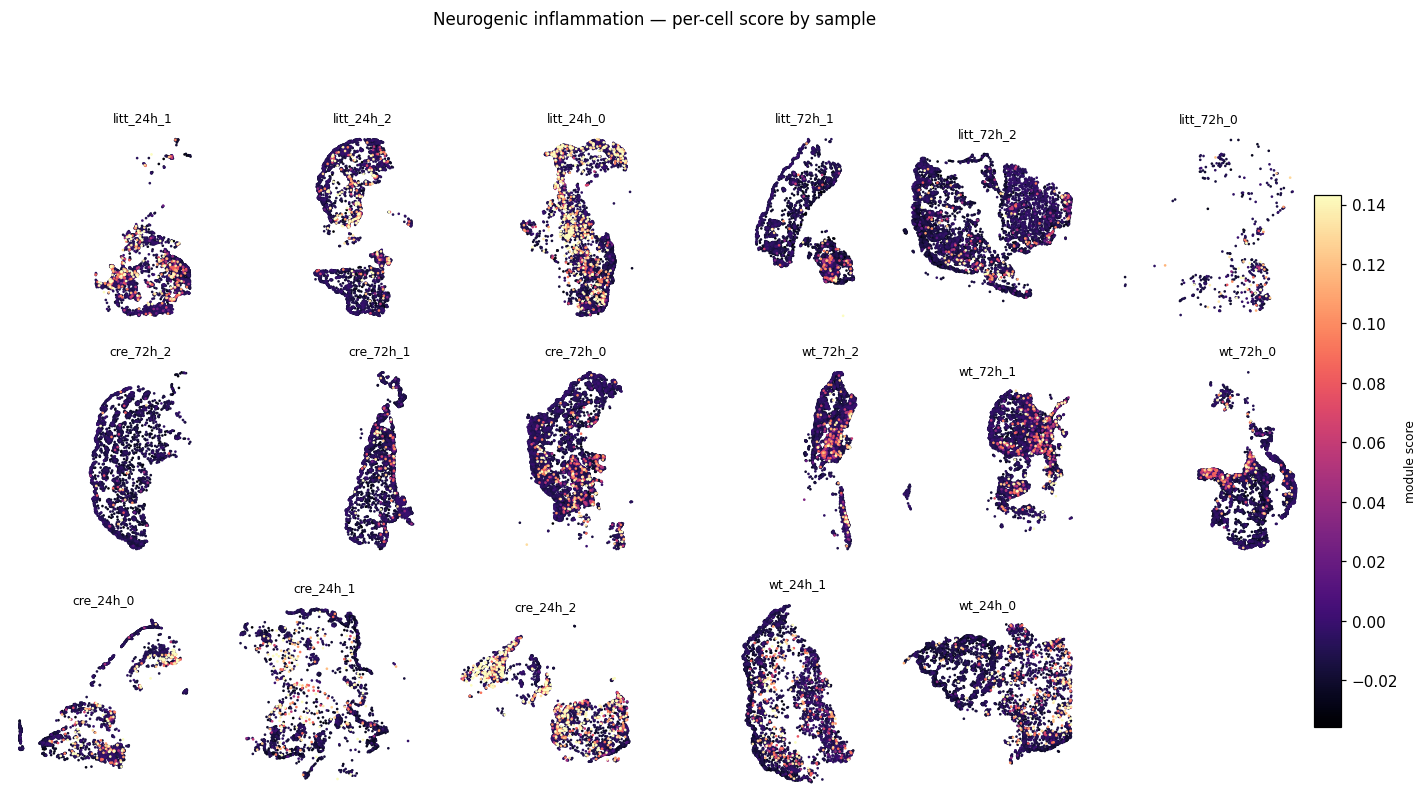

In [8]:
for t in THEMES:
    plot_score_by_sample(
        adata, f'{t}_score',
        out_stem=f'../../results/spatial-tissue-maps/skin_wound_theme_{t}_by_sample',
        title=f'{THEME_LABEL[t]} — per-cell score by sample')

## Neighborhood summaries — theme × compartment and theme × niche

Mean per-cell score in each **cell lineage** and each **CellCharter niche**
(z-scored across groups within a theme for the heatmap; raw means saved to CSV).

saved ../../results/cell-driven-analysis/skin_wound_theme_by_compartment.png/.pdf/.csv


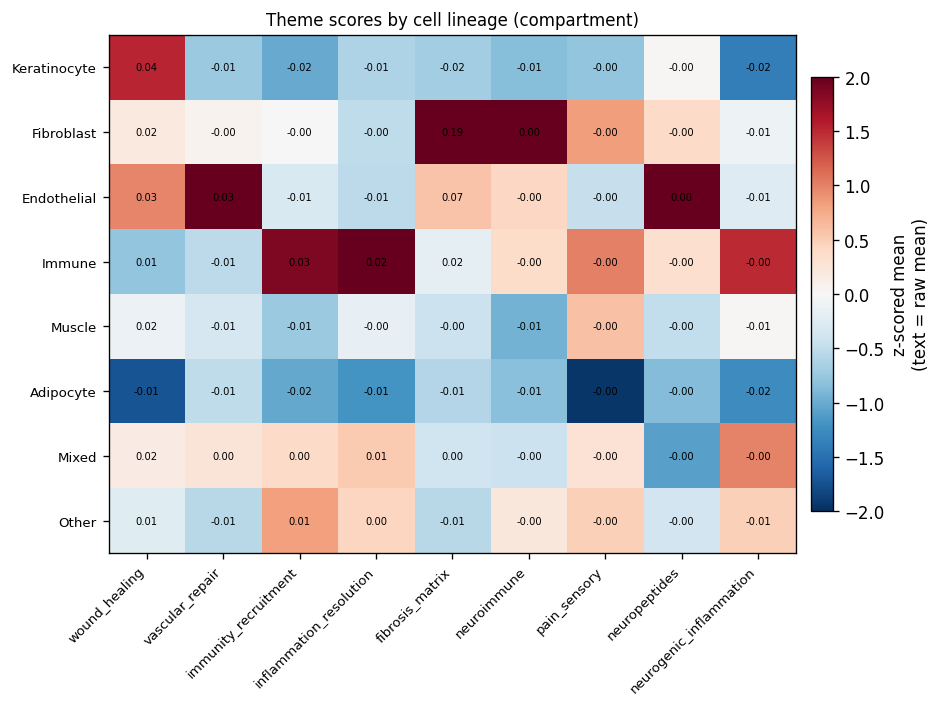

In [9]:
def summary_heatmap(ad, group_col, out_stem, title):
    M = ad.obs.groupby(group_col, observed=True)[score_cols].mean()
    M.columns = [c.replace('_score','') for c in M.columns]
    M.to_csv(out_stem + '.csv')
    Z = (M - M.mean(axis=0)) / (M.std(axis=0) + 1e-9)   # z-score each theme across groups
    fig, ax = plt.subplots(figsize=(0.55*Z.shape[1]+3, 0.5*Z.shape[0]+2), dpi=120)
    im = ax.imshow(Z.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(Z.shape[1])); ax.set_xticklabels(Z.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(Z.shape[0])); ax.set_yticklabels(Z.index, fontsize=8)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            ax.text(j, i, f'{M.values[i,j]:.2f}', ha='center', va='center', fontsize=6,
                    color='black')
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='z-scored mean\n(text = raw mean)')
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_stem + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(out_stem + '.pdf', bbox_inches='tight')
    print('saved', out_stem + '.png/.pdf/.csv')
    plt.show()
    return M

comp_order = [c for c in ['Keratinocyte','Fibroblast','Endothelial','Immune','Muscle',
                          'Adipocyte','Neural/Melanocyte','Mixed','Other']
              if c in set(adata.obs['compartment'])]
adata.obs['compartment'] = pd.Categorical(adata.obs['compartment'], categories=comp_order)
M_comp = summary_heatmap(adata, 'compartment',
    '../../results/cell-driven-analysis/skin_wound_theme_by_compartment',
    'Theme scores by cell lineage (compartment)')

saved ../../results/cell-driven-analysis/skin_wound_theme_by_niche_k12.png/.pdf/.csv


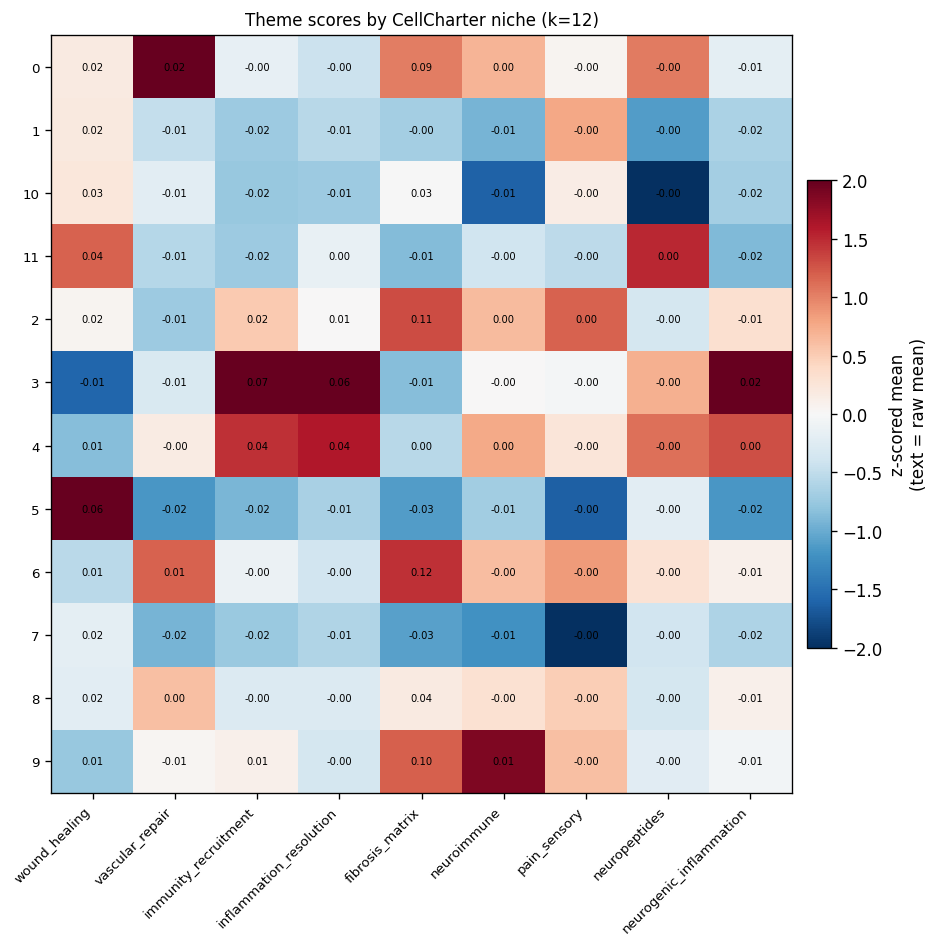

In [10]:
M_niche = summary_heatmap(adata, NICHE,
    '../../results/cell-driven-analysis/skin_wound_theme_by_niche_k12',
    'Theme scores by CellCharter niche (k=12)')

## Per-cell export (all theme scores + compartment + niche)

In [11]:
sp_xy = np.asarray(adata.obsm['spatial'])[:, :2]
out = pd.DataFrame({
    'cell_id': adata.obs_names,
    'x': sp_xy[:, 0], 'y': sp_xy[:, 1],
    'sample_id': adata.obs['sample_id'].astype(str).values,
    'condition': adata.obs['condition'].astype(str).values,
    'genotype': adata.obs['genotype'].astype(str).values,
    'cell_type': adata.obs[ANNOT].astype(str).values,
    'compartment': adata.obs['compartment'].astype(str).values,
    'niche_k12': adata.obs[NICHE].astype(str).values,
})
for c in score_cols:
    out[c] = adata.obs[c].values
out.to_csv('../../results/cell-driven-analysis/skin_wound_cell_theme_scores.csv', index=False)
print('wrote', out.shape, 'to skin_wound_cell_theme_scores.csv')
out.head()

wrote (77401, 18) to skin_wound_cell_theme_scores.csv


,cell_id,x,y,sample_id,condition,genotype,cell_type,compartment,niche_k12,wound_healing_score,vascular_repair_score,immunity_recruitment_score,inflammation_resolution_score,fibrosis_matrix_score,neuroimmune_score,pain_sensory_score,neuropeptides_score,neurogenic_inflammation_score
0,output-XETG00045__0059976__litt_24h__20250725_...,368.014587,3811.147461,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Inflammatory Macrophage (GRN+ chemokine),Immune,4,0.048724,-0.029470,0.028426,0.180704,-0.027625,-0.017593,-0.002304,0.000000,0.000000
1,output-XETG00045__0059976__litt_24h__20250725_...,389.098480,3823.478516,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Interferon-Responsive Regulatory Macrophage,Immune,4,0.041140,-0.023924,0.101365,-0.005910,0.002481,0.040815,-0.009316,-0.002073,-0.012339
2,output-XETG00045__0059976__litt_24h__20250725_...,450.419128,3818.730469,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Stressed Skeletal Muscle Fiber (glycolytic),Muscle,4,-0.020921,0.019363,0.149482,0.116371,0.005875,-0.016932,-0.007210,-0.001604,0.061218
3,output-XETG00045__0059976__litt_24h__20250725_...,376.878601,3817.675049,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Interferon-Responsive Regulatory Macrophage,Immune,4,0.024966,-0.028409,0.004842,0.108308,-0.032898,-0.011551,-0.001421,-0.001580,-0.021552
4,output-XETG00045__0059976__litt_24h__20250725_...,375.687622,3810.113525,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,M2-like Macrophage,Immune,4,0.018155,-0.024903,0.011284,0.059223,-0.042670,-0.015630,-0.010926,-0.004812,-0.019062


## Sample-level aggregation (each section = one replicate)

Collapse the per-cell scores to **one value per sample**, then compare across
sample types. Two resolutions:
- **whole section** — mean score over all cells in the sample;
- **within compartment** — mean score restricted to the lineage most relevant to
  the theme (e.g. fibrosis in fibroblasts). Neuro themes with no clear skin
  compartment fall back to whole-section (flagged `all`).

> **⚠️ Replicate caveat:** the 17 "samples" are KMeans-separated spatial sections,
> not confirmed distinct animals. SEM/tests below are only valid as biological
> statistics if each section = one mouse — confirm with the wet-lab before
> publishing. See `results/sample-level/README.md`.

In [12]:
from scipy import stats

# lineage most relevant to each theme (None -> use whole section)
THEME_COMPARTMENT = {
    'wound_healing':'Keratinocyte', 'vascular_repair':'Endothelial',
    'immunity_recruitment':'Immune', 'inflammation_resolution':'Immune',
    'fibrosis_matrix':'Fibroblast', 'neuroimmune':'Immune',
    'pain_sensory':None, 'neuropeptides':None, 'neurogenic_inflammation':'Immune',
}
obs = adata.obs.copy()
obs['timepoint'] = obs['condition'].astype(str).str.split('_').str[-1]

rows = []
for sid, sub in obs.groupby('sample_id', observed=True):
    r = {'sample_id': sid, 'condition': str(sub['condition'].iloc[0]),
         'genotype': str(sub['genotype'].iloc[0]), 'timepoint': str(sub['timepoint'].iloc[0]),
         'n_cells': len(sub)}
    for t in THEMES:
        col = f'{t}_score'
        r[f'{t}__whole'] = sub[col].mean()
        comp = THEME_COMPARTMENT[t]
        if comp is None:
            r[f'{t}__comp'] = sub[col].mean(); r[f'{t}__comp_name'] = 'all'
            r[f'{t}__comp_n'] = len(sub)
        else:
            m = sub['compartment'].astype(str) == comp
            r[f'{t}__comp'] = sub.loc[m, col].mean() if m.any() else np.nan
            r[f'{t}__comp_name'] = comp; r[f'{t}__comp_n'] = int(m.sum())
    rows.append(r)
samp = pd.DataFrame(rows)
samp.to_csv('../../results/sample-level/skin_wound_theme_sample_means.csv', index=False)
print('per-sample theme means:', samp.shape)
samp[['sample_id','condition','genotype','timepoint','n_cells']]

per-sample theme means: (17, 41)


,sample_id,condition,genotype,timepoint,n_cells
0,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h,cre,24h,2610
1,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h,cre,24h,2173
2,output-XETG00045__0059976__cre_24h__20250725__...,cre_24h,cre,24h,2908
3,output-XETG00045__0059976__cre_72h__20250725__...,cre_72h,cre,72h,8550
4,output-XETG00045__0059976__cre_72h__20250725__...,cre_72h,cre,72h,4456
5,output-XETG00045__0059976__cre_72h__20250725__...,cre_72h,cre,72h,4116
6,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,24h,4727
7,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,24h,4105
8,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,24h,4619
9,output-XETG00045__0059976__litt_72h__20250725_...,litt_72h,litt,72h,506


In [13]:
def group_summary(df, group_cols, kind):
    """Long-format mean/sem/n across samples, for score kind 'whole' or 'comp'."""
    recs = []
    for keys, sub in df.groupby(group_cols, observed=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        for t in THEMES:
            v = sub[f'{t}__{kind}'].dropna()
            rec = dict(zip(group_cols, keys))
            rec.update({'theme': t, 'resolution': kind, 'n_samples': int(v.size),
                        'mean': v.mean(), 'sem': v.sem() if v.size > 1 else np.nan})
            recs.append(rec)
    return pd.DataFrame(recs)

cond_stats = pd.concat([group_summary(samp, ['condition'], 'whole'),
                        group_summary(samp, ['condition'], 'comp')], ignore_index=True)
cond_stats.to_csv('../../results/sample-level/skin_wound_theme_stats_by_condition.csv', index=False)
print('by-condition stats:', cond_stats.shape)
cond_stats.head(12)

by-condition stats: (108, 6)


,condition,theme,resolution,n_samples,mean,sem
0,cre_24h,wound_healing,whole,3,0.026937,0.002641
1,cre_24h,vascular_repair,whole,3,-0.006069,0.000877
2,cre_24h,immunity_recruitment,whole,3,0.012735,0.014725
3,cre_24h,inflammation_resolution,whole,3,0.008222,0.009723
4,cre_24h,fibrosis_matrix,whole,3,0.011513,0.008574
5,cre_24h,neuroimmune,whole,3,-0.000668,0.001078
6,cre_24h,pain_sensory,whole,3,-0.001529,0.000134
7,cre_24h,neuropeptides,whole,3,-0.000190,0.000163
8,cre_24h,neurogenic_inflammation,whole,3,0.001273,0.006409
9,cre_72h,wound_healing,whole,3,0.020345,0.003376


In [14]:
# Genotype within timepoint: mean/sem + pairwise Welch t-tests among genotypes
GENOS = ['litt','cre','wt']
recs, tests = [], []
for tp, sub_tp in samp.groupby('timepoint', observed=True):
    for t in THEMES:
        for kind in ['whole','comp']:
            by = {g: sub_tp.loc[sub_tp.genotype == g, f'{t}__{kind}'].dropna().values
                  for g in GENOS}
            for g in GENOS:
                v = by[g]
                recs.append({'timepoint': tp, 'genotype': g, 'theme': t, 'resolution': kind,
                             'n_samples': v.size, 'mean': v.mean() if v.size else np.nan,
                             'sem': v.std(ddof=1)/np.sqrt(v.size) if v.size > 1 else np.nan})
            for a, b in [('cre','litt'), ('cre','wt'), ('litt','wt')]:
                x, y = by[a], by[b]
                if x.size > 1 and y.size > 1:
                    tstat, p = stats.ttest_ind(x, y, equal_var=False)
                else:
                    tstat, p = np.nan, np.nan
                tests.append({'timepoint': tp, 'theme': t, 'resolution': kind,
                              'contrast': f'{a}_vs_{b}', 'mean_diff': x.mean()-y.mean(),
                              't': tstat, 'p': p, 'n_a': x.size, 'n_b': y.size})
gwt_stats = pd.DataFrame(recs)
gwt_tests = pd.DataFrame(tests)
gwt_stats.to_csv('../../results/sample-level/skin_wound_theme_stats_genotype_within_timepoint.csv', index=False)
gwt_tests.to_csv('../../results/sample-level/skin_wound_theme_tests_genotype_within_timepoint.csv', index=False)
print('genotype-within-timepoint stats:', gwt_stats.shape, '| tests:', gwt_tests.shape)
print('NOTE: t-tests are low-power (n=2-3) and assume each section is an independent mouse.')
gwt_tests.head(9)

genotype-within-timepoint stats: (108, 7) | tests: (108, 9)
NOTE: t-tests are low-power (n=2-3) and assume each section is an independent mouse.


,timepoint,theme,resolution,contrast,mean_diff,t,p,n_a,n_b
0,24h,wound_healing,whole,cre_vs_litt,0.010009,3.189769,0.041639,3,3
1,24h,wound_healing,whole,cre_vs_wt,-0.002014,-0.263867,0.828028,3,2
2,24h,wound_healing,whole,litt_vs_wt,-0.012023,-1.633618,0.330717,3,2
3,24h,wound_healing,comp,cre_vs_litt,0.010743,1.505457,0.229312,3,3
4,24h,wound_healing,comp,cre_vs_wt,0.002816,0.333568,0.782691,3,2
5,24h,wound_healing,comp,litt_vs_wt,-0.007927,-0.789982,0.503693,3,2
6,24h,vascular_repair,whole,cre_vs_litt,0.000579,0.497719,0.645257,3,3
7,24h,vascular_repair,whole,cre_vs_wt,0.001641,1.273806,0.307242,3,2
8,24h,vascular_repair,whole,litt_vs_wt,0.001062,0.874245,0.464991,3,2


### Bar plots — condition mean ± SEM (points = individual samples)

saved ../../results/sample-level/skin_wound_theme_bars_by_condition_wholesection.png/.pdf


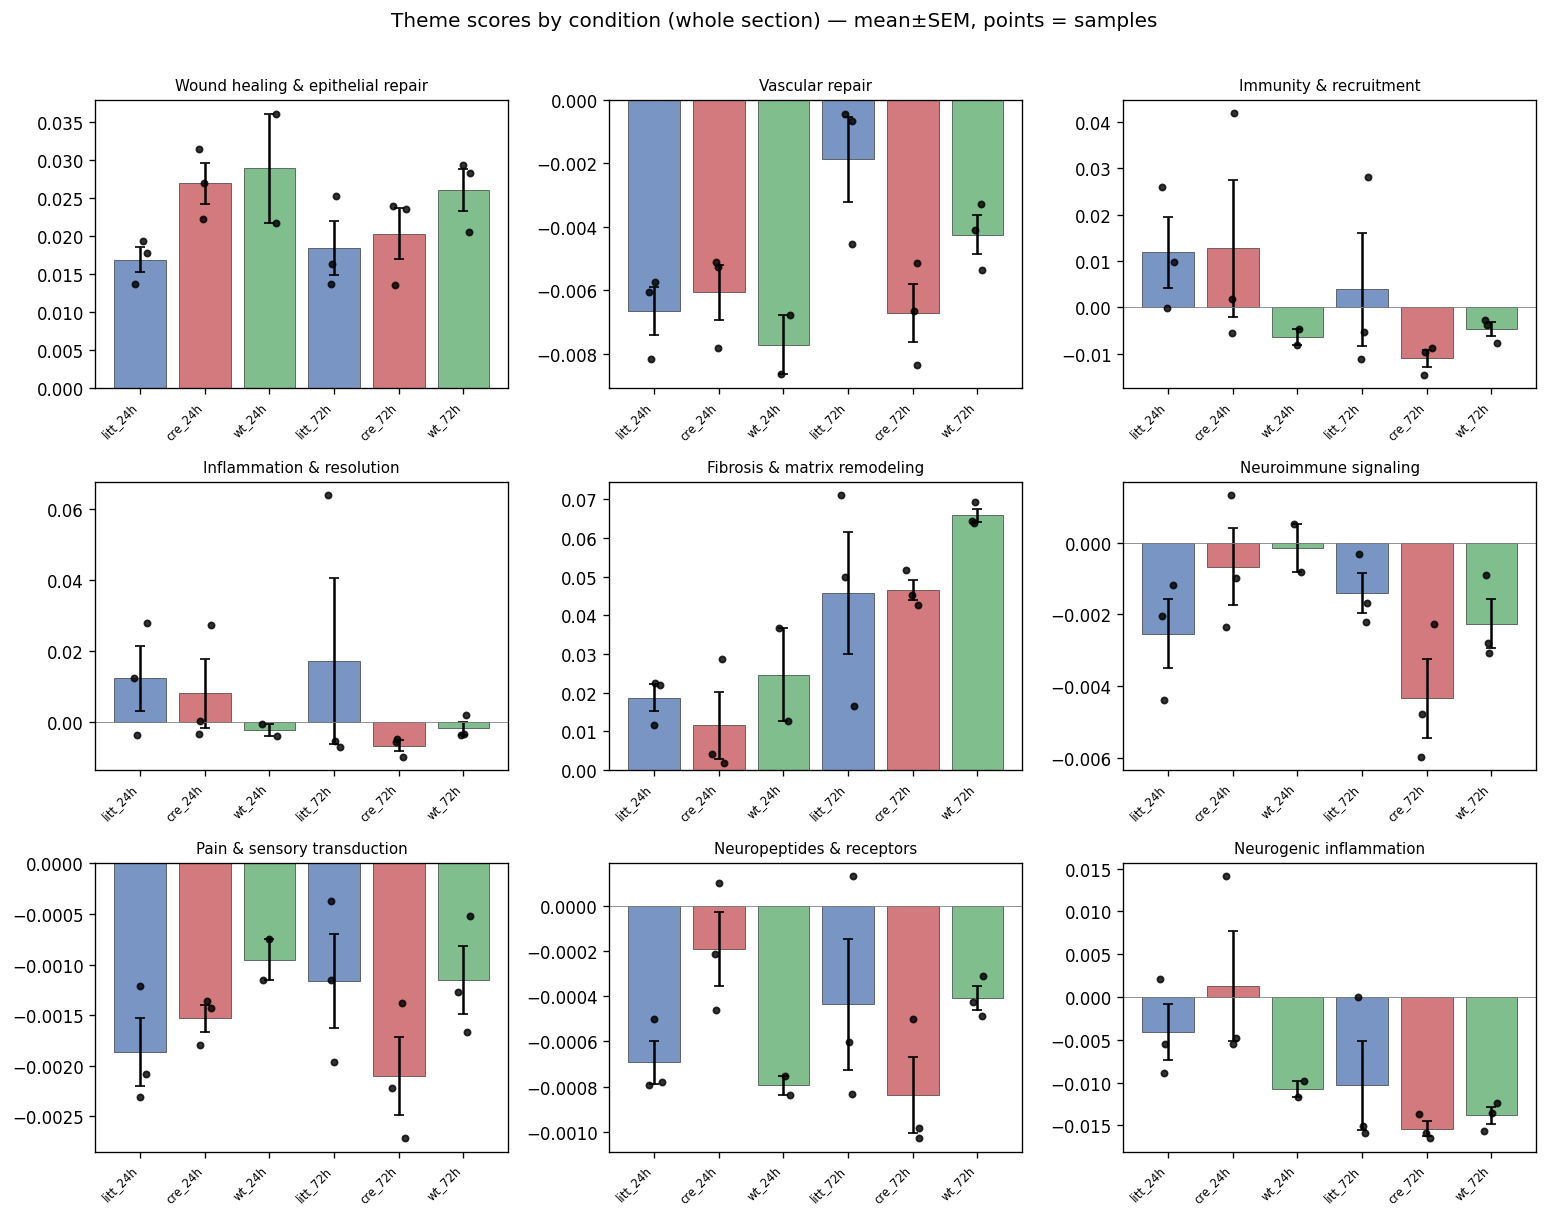

saved ../../results/sample-level/skin_wound_theme_bars_by_condition_within_compartment.png/.pdf


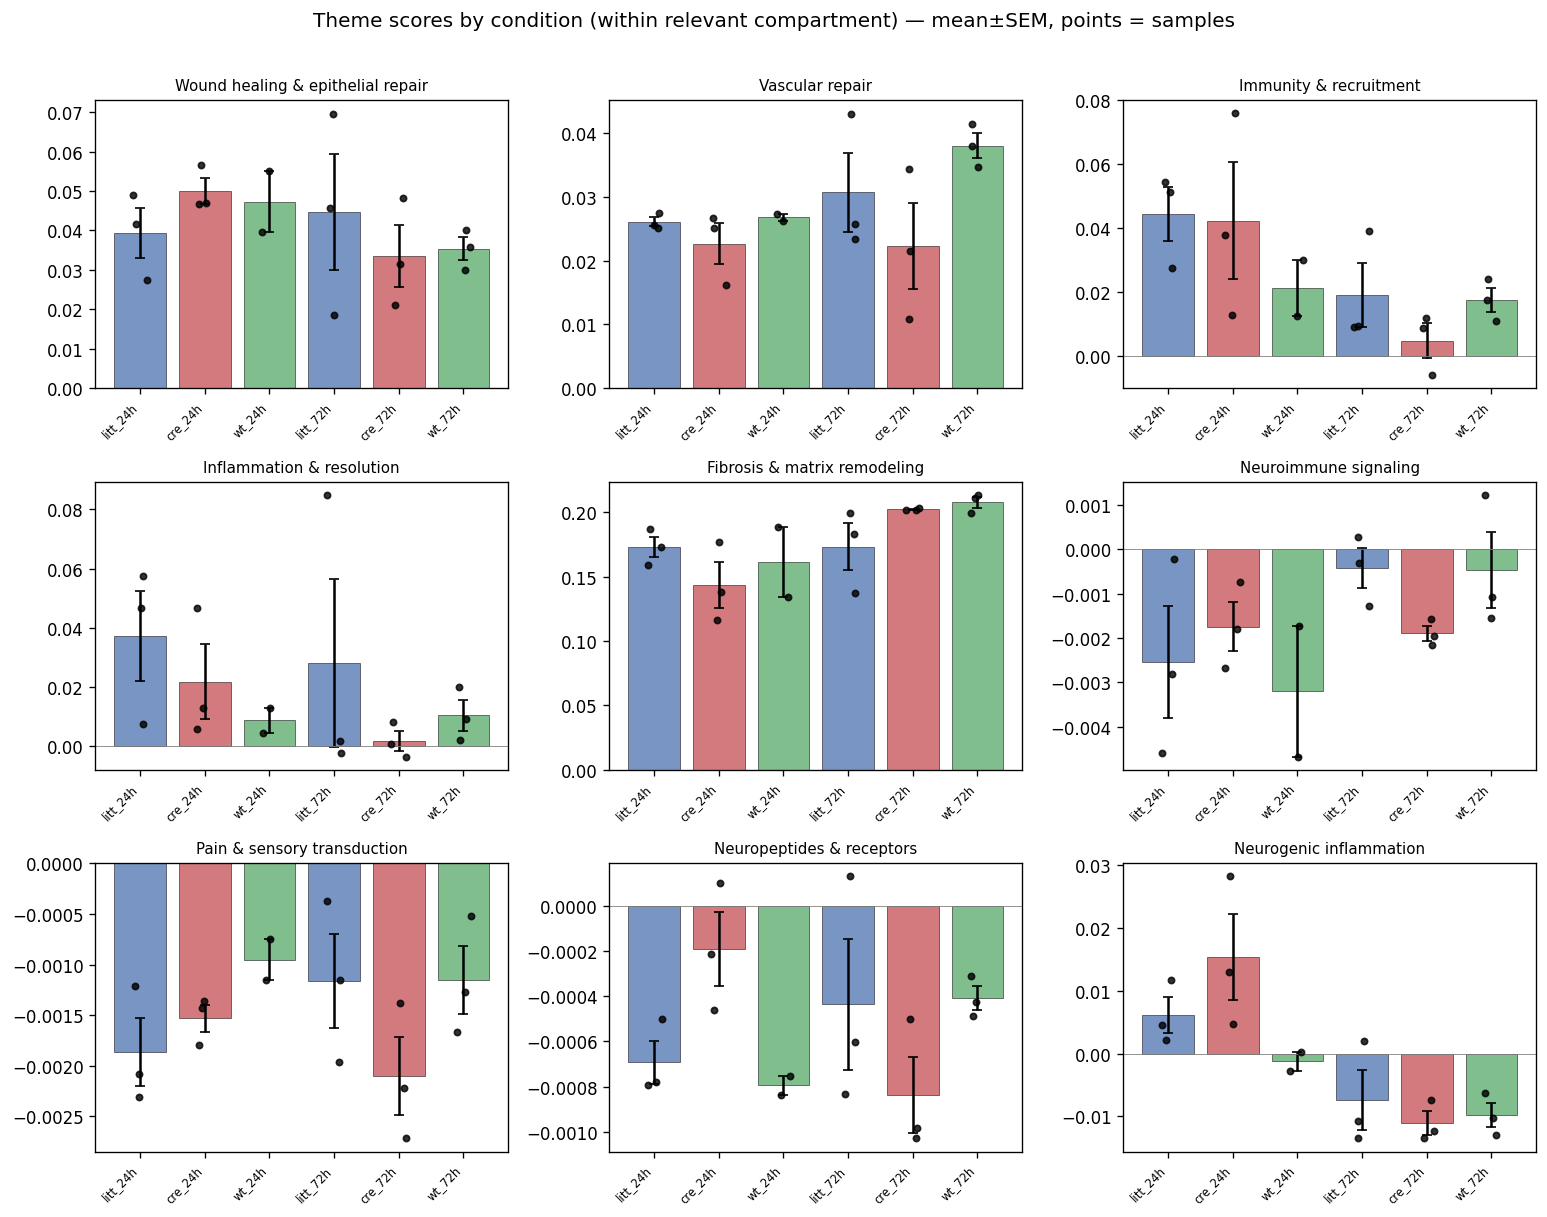

In [15]:
CONDS = ['litt_24h','cre_24h','wt_24h','litt_72h','cre_72h','wt_72h']
GENO_COLORS = {'litt':'#4C72B0', 'cre':'#C44E52', 'wt':'#55A868'}

def barpanel_by_condition(df, kind, out_stem, suptitle):
    conds = [c for c in CONDS if c in set(df['condition'])]
    xcolors = [GENO_COLORS.get(c.split('_')[0], '#888') for c in conds]
    fig, axes = plt.subplots(3, 3, figsize=(13, 10), dpi=120)
    for ax, t in zip(axes.ravel(), THEMES):
        col = f'{t}__{kind}'
        means = [df.loc[df.condition == c, col].mean() for c in conds]
        sems = [df.loc[df.condition == c, col].sem() for c in conds]
        x = np.arange(len(conds))
        ax.bar(x, means, yerr=sems, capsize=3, color=xcolors, alpha=0.75, edgecolor='k', linewidth=0.4)
        for xi, c in zip(x, conds):
            pts = df.loc[df.condition == c, col].dropna().values
            ax.scatter(np.full(pts.size, xi) + np.random.uniform(-0.12, 0.12, pts.size),
                       pts, s=14, color='k', zorder=3, alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(conds, rotation=45, ha='right', fontsize=7)
        ax.set_title(THEME_LABEL[t], fontsize=9)
        ax.axhline(0, color='grey', lw=0.5)
    fig.suptitle(suptitle, fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(out_stem + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(out_stem + '.pdf', bbox_inches='tight')
    print('saved', out_stem + '.png/.pdf'); plt.show()

barpanel_by_condition(samp, 'whole',
    '../../results/sample-level/skin_wound_theme_bars_by_condition_wholesection',
    'Theme scores by condition (whole section) — mean±SEM, points = samples')
barpanel_by_condition(samp, 'comp',
    '../../results/sample-level/skin_wound_theme_bars_by_condition_within_compartment',
    'Theme scores by condition (within relevant compartment) — mean±SEM, points = samples')

### Bar plots — genotype within timepoint (grouped)

saved ../../results/sample-level/skin_wound_theme_bars_genotype_within_timepoint_wholesection.png/.pdf


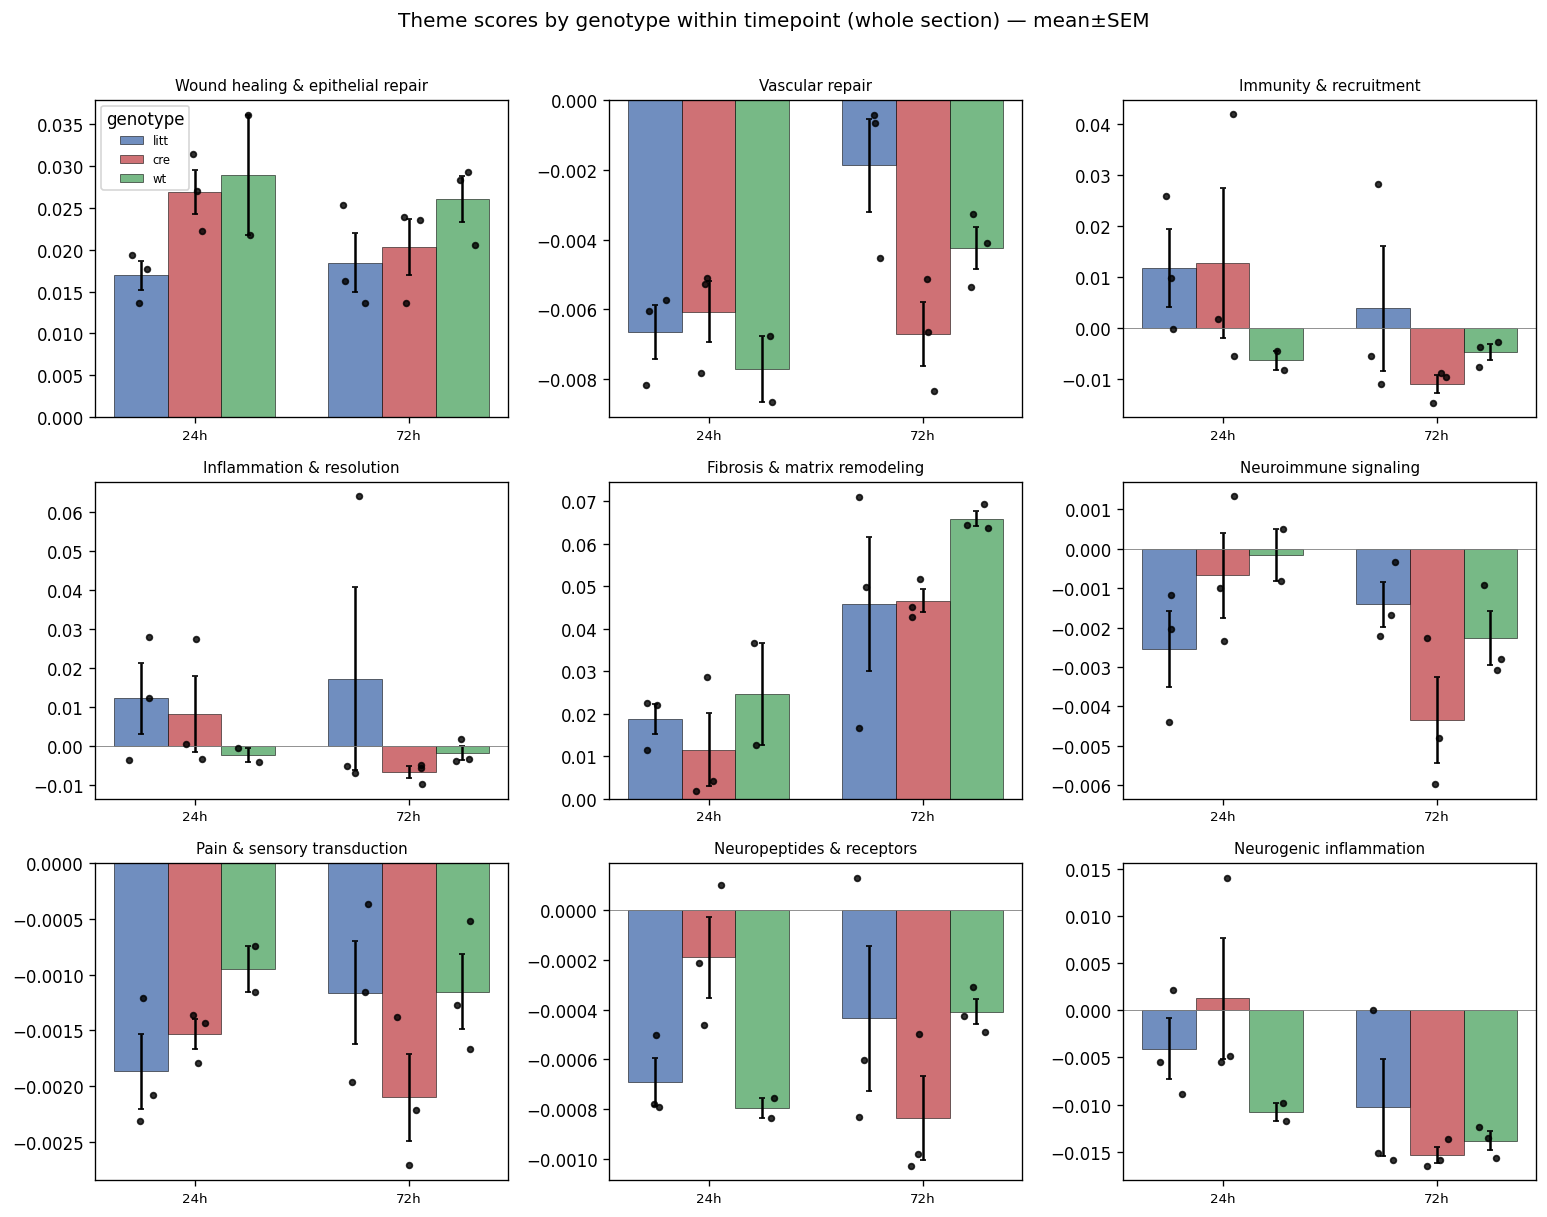

saved ../../results/sample-level/skin_wound_theme_bars_genotype_within_timepoint_within_compartment.png/.pdf


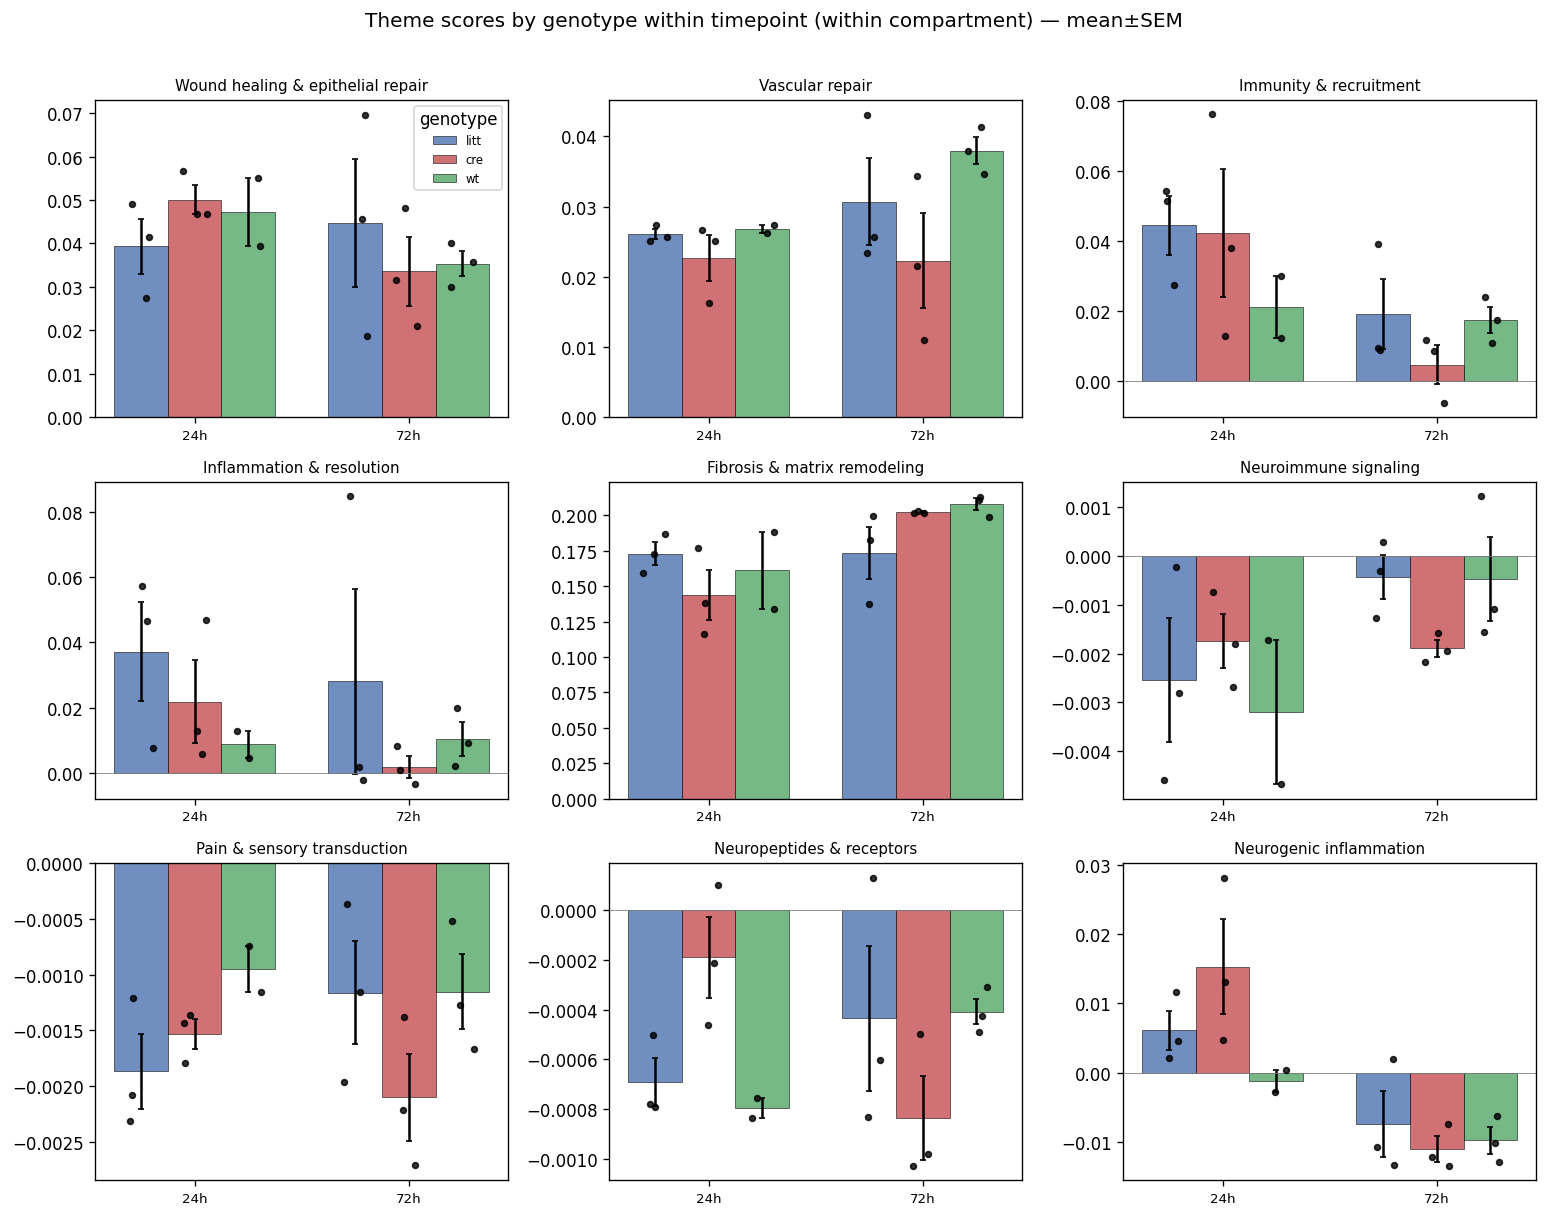

In [16]:
def barpanel_geno_within_tp(df, kind, out_stem, suptitle):
    tps = ['24h','72h']; tps = [tp for tp in tps if tp in set(df['timepoint'])]
    fig, axes = plt.subplots(3, 3, figsize=(13, 10), dpi=120)
    width = 0.25
    for ax, t in zip(axes.ravel(), THEMES):
        col = f'{t}__{kind}'
        base = np.arange(len(tps))
        for gi, g in enumerate(GENOS):
            means, sems, xs = [], [], []
            for ti, tp in enumerate(tps):
                v = df.loc[(df.timepoint == tp) & (df.genotype == g), col].dropna().values
                means.append(v.mean() if v.size else np.nan)
                sems.append(v.std(ddof=1)/np.sqrt(v.size) if v.size > 1 else np.nan)
                xpos = base[ti] + (gi-1)*width
                xs.append(xpos)
                ax.scatter(np.full(v.size, xpos) + np.random.uniform(-0.06, 0.06, v.size),
                           v, s=12, color='k', zorder=3, alpha=0.8)
            ax.bar(xs, means, width, yerr=sems, capsize=2, label=g,
                   color=GENO_COLORS[g], alpha=0.8, edgecolor='k', linewidth=0.4)
        ax.set_xticks(base); ax.set_xticklabels(tps, fontsize=8)
        ax.set_title(THEME_LABEL[t], fontsize=9); ax.axhline(0, color='grey', lw=0.5)
    axes.ravel()[0].legend(fontsize=7, title='genotype')
    fig.suptitle(suptitle, fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(out_stem + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(out_stem + '.pdf', bbox_inches='tight')
    print('saved', out_stem + '.png/.pdf'); plt.show()

barpanel_geno_within_tp(samp, 'whole',
    '../../results/sample-level/skin_wound_theme_bars_genotype_within_timepoint_wholesection',
    'Theme scores by genotype within timepoint (whole section) — mean±SEM')
barpanel_geno_within_tp(samp, 'comp',
    '../../results/sample-level/skin_wound_theme_bars_genotype_within_timepoint_within_compartment',
    'Theme scores by genotype within timepoint (within compartment) — mean±SEM')

## ⚠️ Interpretation note — neuro/sensory themes

The compartment/niche summaries above show that the five **tissue-repair themes**
(wound healing, vascular, immunity, inflammation, fibrosis) map cleanly onto the
expected lineages and carry real signal.

The four **neuro/sensory themes** (neuroimmune, pain & sensory transduction,
neuropeptides, neurogenic inflammation) are near-zero across every compartment.
This is expected biology, not a pipeline artifact: the neurons that express these
programs (`Trpv1`, `Scn10a`, `Calca/Tac1`, neuropeptides) have their cell bodies
in the **dorsal root ganglia**, not the skin. The skin contains only thin free
nerve endings/axons, which Xenium does not segment into whole cells. **Per-cell**
scores for these themes should therefore be treated as low-confidence; a
neighborhood-level readout (do keratinocytes/immune cells *adjacent to* sparse
neuropeptide-receptor signal upregulate neurogenic-inflammation programs?) is the
more defensible framing if these themes are pursued.